# Spaceship Titanic — Multi-Agent v2 (Improved)

Improved version of the multi-agent data science workflow (`multi_agent_data_science_markdowns`), iteration **v2**.

## Agent 1 — Data Preparation · Phase A: Data Intake & Initial Analysis

### Context Received

Reports read: `final_recommendations.md`, `leaderboard_tracking.md`, `improvement_opportunities.md` (v1 run).

Key inherited findings:

1. **Best LB so far: 0.80289** (stacked ensemble, fixed threshold t=0.500); tuned HGB OOF = 0.8108.
2. OOF ranking did not match LB ranking — OOF-optimized thresholds overfit; fixed t=0.500 generalized best.
3. Group structure (`GroupId` from `PassengerId`) is a strong signal; group-safe CV (`GroupKFold`) is mandatory to avoid leakage.
4. Plateau reached via model/threshold tweaks → v2 should look for gains in **data prep and feature engineering**, plus LightGBM/CatBoost-class models.

How this shapes Phase A: re-run EDA from raw data with fresh eyes, with special attention to group structure, spending columns (skew/zero-inflation), CryoSleep↔spending logical constraints, and Cabin decomposition — the areas most likely to yield new features.

In [1]:
# Setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

ROOT = Path("..").resolve() if Path("../data/train.csv").exists() else Path(".").resolve()
DATA = ROOT / "data"
FIG = ROOT / "reports" / "figures_v2"
FIG.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
print(f"train: {train.shape}, test: {test.shape}")
train.head()

train: (8693, 14), test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### A.1 Problem Type & Target

- **Problem type:** binary classification (supervised). Target `Transported` is boolean and exists only in train.
- **Evaluation:** Kaggle accuracy on hidden test labels.
- **Unit of prediction:** one passenger; passengers travel in groups (`PassengerId = GGGG_PP`) → group leakage risk in CV.

In [2]:
# A.2 Dataset overview: schema, dtypes, duplicates, cardinality
def overview(df, name):
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    })
    print(f"--- {name}: {df.shape[0]} rows x {df.shape[1]} cols | duplicates: {df.duplicated().sum()} | mem: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    return out

schema_train = overview(train, "train")
schema_test = overview(test, "test")
display(schema_train)
display(schema_test)

--- train: 8693 rows x 14 cols | duplicates: 0 | mem: 3.8 MB
--- test: 4277 rows x 13 cols | duplicates: 0 | mem: 1.9 MB


,dtype,n_unique,missing,missing_pct
PassengerId,object,8693,0,0.00
HomePlanet,object,3,201,2.31
CryoSleep,object,2,217,2.50
Cabin,object,6560,199,2.29
Destination,object,3,182,2.09
Age,float64,80,179,2.06
VIP,object,2,203,2.34
RoomService,float64,1273,181,2.08
FoodCourt,float64,1507,183,2.11
ShoppingMall,float64,1115,208,2.39


,dtype,n_unique,missing,missing_pct
PassengerId,object,4277,0,0.00
HomePlanet,object,3,87,2.03
CryoSleep,object,2,93,2.17
Cabin,object,3265,100,2.34
Destination,object,3,92,2.15
Age,float64,79,91,2.13
VIP,object,2,93,2.17
RoomService,float64,842,82,1.92
FoodCourt,float64,902,106,2.48
ShoppingMall,float64,715,98,2.29


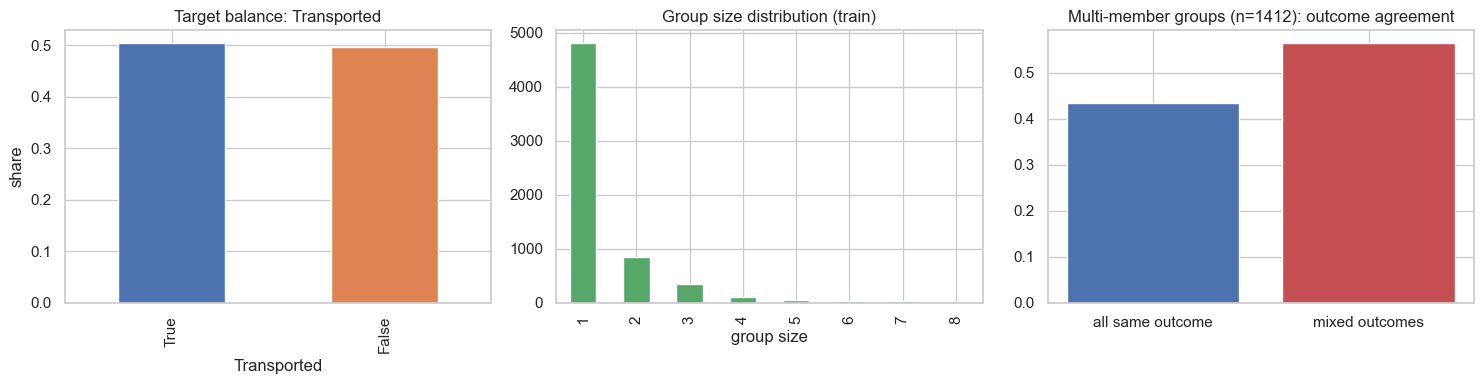

Target rate: 0.5036
Groups in train: 6217 | multi-member groups: 1412 | share with identical outcome: 0.436


In [3]:
# A.3 Target balance + group structure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train["Transported"].value_counts(normalize=True).plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452"])
axes[0].set_title("Target balance: Transported")
axes[0].set_ylabel("share")

grp = train["PassengerId"].str.split("_").str[0]
group_sizes = grp.value_counts().value_counts().sort_index()
group_sizes.plot.bar(ax=axes[1], color="#55a868")
axes[1].set_title("Group size distribution (train)")
axes[1].set_xlabel("group size")

# Within-group target agreement: do members of a group share the same outcome?
g = train.assign(GroupId=grp).groupby("GroupId")["Transported"]
multi = g.count()[g.count() > 1].index
agree = train.assign(GroupId=grp).query("GroupId in @multi").groupby("GroupId")["Transported"].apply(lambda s: s.nunique() == 1)
axes[2].bar(["all same outcome", "mixed outcomes"], [agree.mean(), 1 - agree.mean()], color=["#4c72b0", "#c44e52"])
axes[2].set_title(f"Multi-member groups (n={len(agree)}): outcome agreement")
plt.tight_layout()
plt.savefig(FIG / "a_target_groups.png", dpi=110)
plt.show()

print(f"Target rate: {train['Transported'].mean():.4f}")
print(f"Groups in train: {grp.nunique()} | multi-member groups: {len(agree)} | share with identical outcome: {agree.mean():.3f}")

,train_missing_pct,test_missing_pct
CryoSleep,2.50,2.17
ShoppingMall,2.39,2.29
VIP,2.34,2.17
HomePlanet,2.31,2.03
Name,2.30,2.20
Cabin,2.29,2.34
VRDeck,2.16,1.87
FoodCourt,2.11,2.48
Spa,2.11,2.36
Destination,2.09,2.15


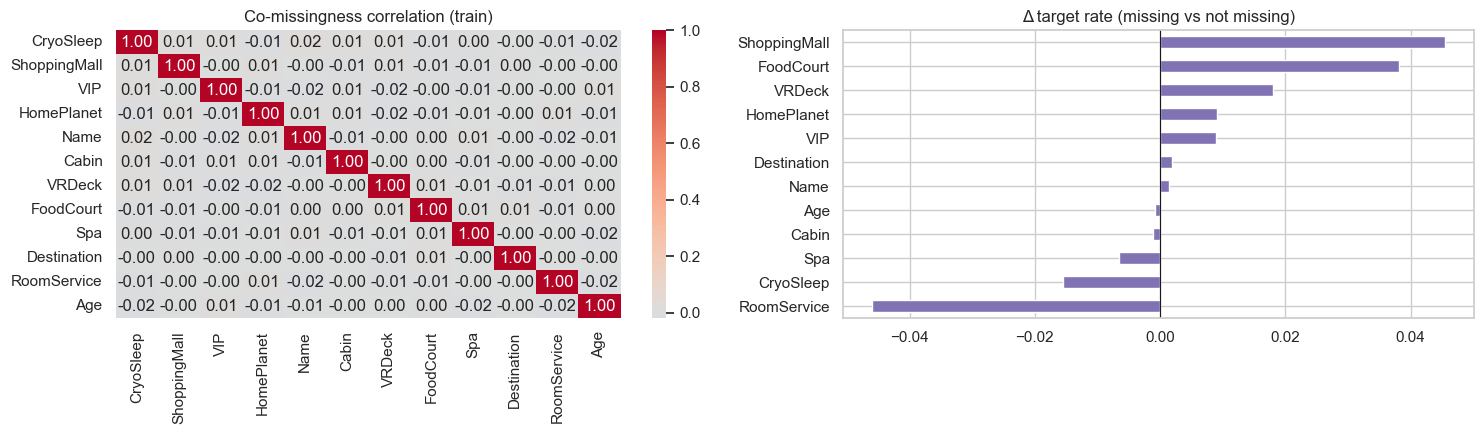

Rows with ≥1 missing value: train 24.0%, test 23.3%


In [4]:
# A.4 Missing value analysis (per column + co-missing patterns + relation to target)
miss = pd.DataFrame({
    "train_missing_pct": (train.isna().mean() * 100).round(2),
    "test_missing_pct": (test.isna().mean() * 100).round(2).reindex(train.columns),
}).sort_values("train_missing_pct", ascending=False)
display(miss)

cols_with_na = miss[miss["train_missing_pct"] > 0].index.tolist()
cols_with_na = [c for c in cols_with_na if c != "Transported"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.heatmap(train[cols_with_na].isna().corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Co-missingness correlation (train)")

# Is missingness informative about the target?
mnar = pd.Series({c: train.groupby(train[c].isna())["Transported"].mean().diff().iloc[-1] for c in cols_with_na})
mnar.sort_values().plot.barh(ax=axes[1], color="#8172b3")
axes[1].set_title("Δ target rate (missing vs not missing)")
axes[1].axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.savefig(FIG / "a_missingness.png", dpi=110)
plt.show()

print(f"Rows with ≥1 missing value: train {train[cols_with_na].isna().any(axis=1).mean()*100:.1f}%, "
      f"test {test[[c for c in cols_with_na if c in test]].isna().any(axis=1).mean()*100:.1f}%")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,zero_pct
Age,8514.0,28.83,14.49,0.0,19.0,27.0,38.0,79.0,0.42,0.10,2.05
RoomService,8512.0,224.69,666.72,0.0,0.0,0.0,47.0,14327.0,6.33,65.27,64.16
FoodCourt,8510.0,458.08,1611.49,0.0,0.0,0.0,76.0,29813.0,7.10,73.31,62.76
ShoppingMall,8485.0,173.73,604.70,0.0,0.0,0.0,27.0,23492.0,12.63,328.87,64.27
Spa,8510.0,311.14,1136.71,0.0,0.0,0.0,59.0,22408.0,7.64,81.20,61.24
VRDeck,8505.0,304.85,1145.72,0.0,0.0,0.0,46.0,24133.0,7.82,86.01,63.21


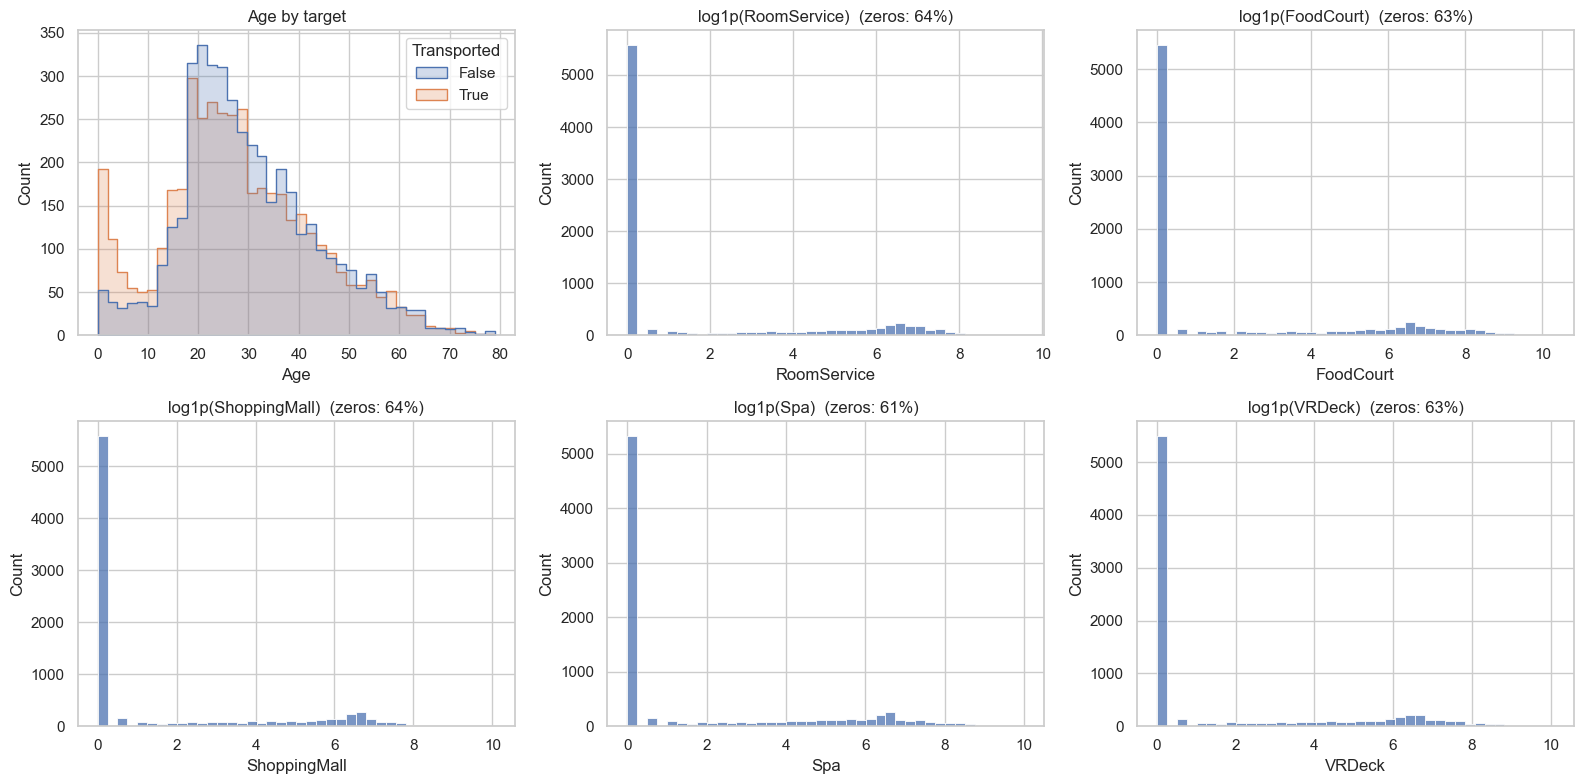

In [5]:
# A.5 Numeric distributions: Age + zero-inflated, skewed spending columns
SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
num_stats = train[["Age"] + SPEND].describe().T
num_stats["skew"] = train[["Age"] + SPEND].skew()
num_stats["kurtosis"] = train[["Age"] + SPEND].kurtosis()
num_stats["zero_pct"] = (train[["Age"] + SPEND] == 0).mean() * 100
display(num_stats.round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sns.histplot(data=train, x="Age", hue="Transported", bins=40, ax=axes[0, 0], element="step")
axes[0, 0].set_title("Age by target")
for ax, c in zip(axes.ravel()[1:], SPEND):
    sns.histplot(np.log1p(train[c].dropna()), bins=40, ax=ax, color="#4c72b0")
    ax.set_title(f"log1p({c})  (zeros: {(train[c]==0).mean()*100:.0f}%)")
plt.tight_layout()
plt.savefig(FIG / "a_numeric_dists.png", dpi=110)
plt.show()

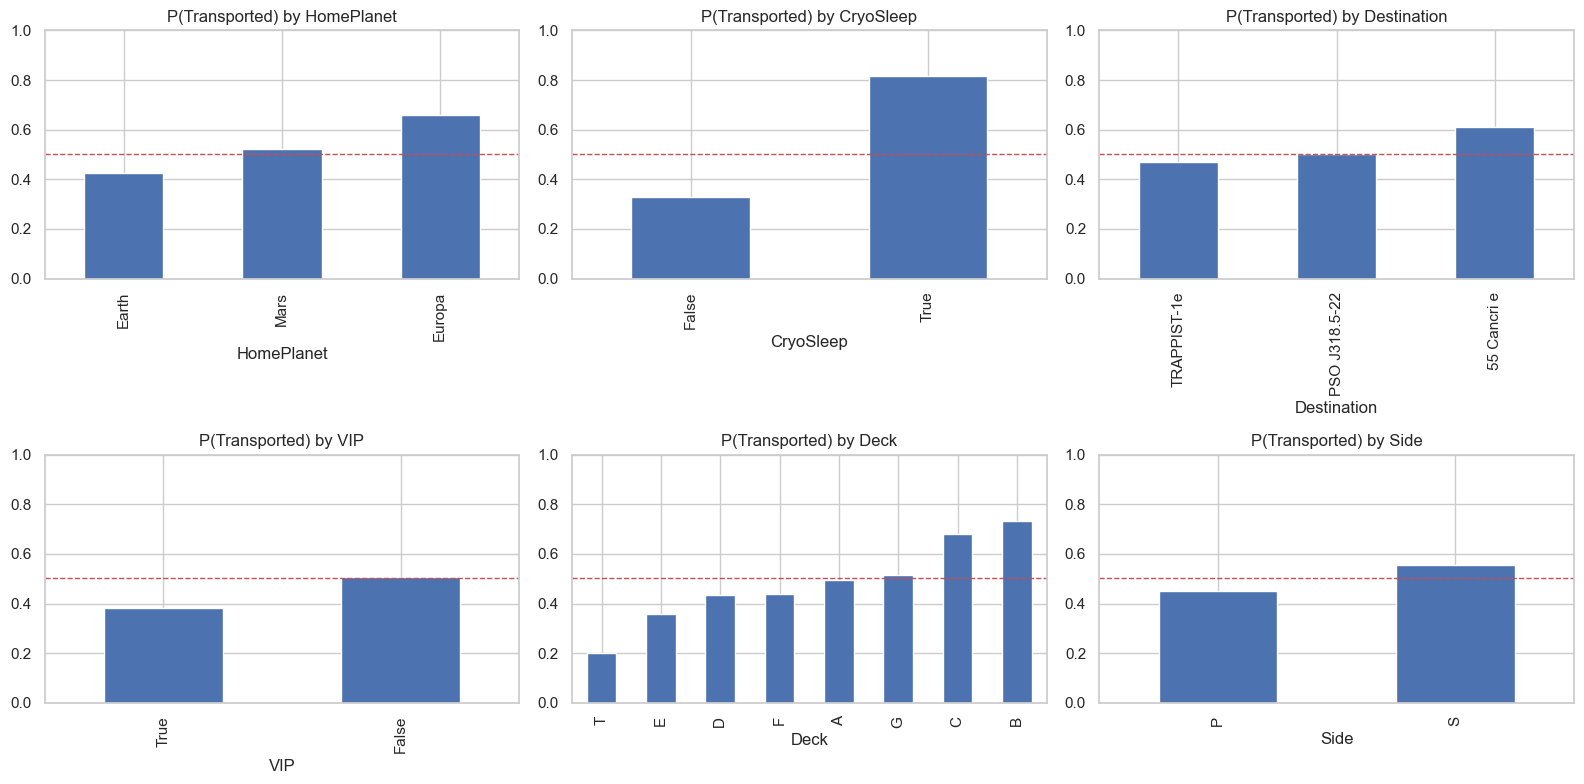

Total spend by CryoSleep: {False: np.float64(12228502.0), True: np.float64(0.0)}
CryoSleep=True passengers with ANY spend > 0: 0


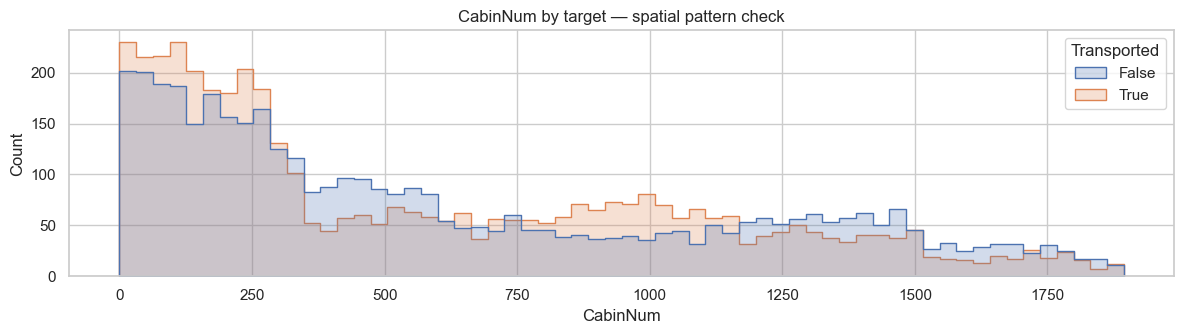

In [6]:
# A.6 Categorical features vs target (+ Cabin decomposition)
cab = train["Cabin"].str.split("/", expand=True)
cab.columns = ["Deck", "CabinNum", "Side"]
train_eda = pd.concat([train, cab], axis=1)
train_eda["CabinNum"] = pd.to_numeric(train_eda["CabinNum"], errors="coerce")

cats = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cats):
    rates = train_eda.groupby(c)["Transported"].agg(["mean", "count"]).sort_values("mean")
    rates["mean"].plot.bar(ax=ax, color="#4c72b0")
    ax.axhline(train["Transported"].mean(), color="r", ls="--", lw=1)
    ax.set_title(f"P(Transported) by {c}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG / "a_categorical_rates.png", dpi=110)
plt.show()

# CryoSleep ↔ spending logical constraint
cryo_spend = train_eda.groupby("CryoSleep")[SPEND].sum().sum(axis=1)
print("Total spend by CryoSleep:", dict(cryo_spend))
print(f"CryoSleep=True passengers with ANY spend > 0: "
      f"{(train_eda[train_eda['CryoSleep'] == True][SPEND].fillna(0).sum(axis=1) > 0).sum()}")

# CabinNum vs target (spatial signal)
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.histplot(data=train_eda.dropna(subset=["CabinNum"]), x="CabinNum", hue="Transported", bins=60, element="step", ax=ax)
ax.set_title("CabinNum by target — spatial pattern check")
plt.tight_layout()
plt.savefig(FIG / "a_cabinnum.png", dpi=110)
plt.show()

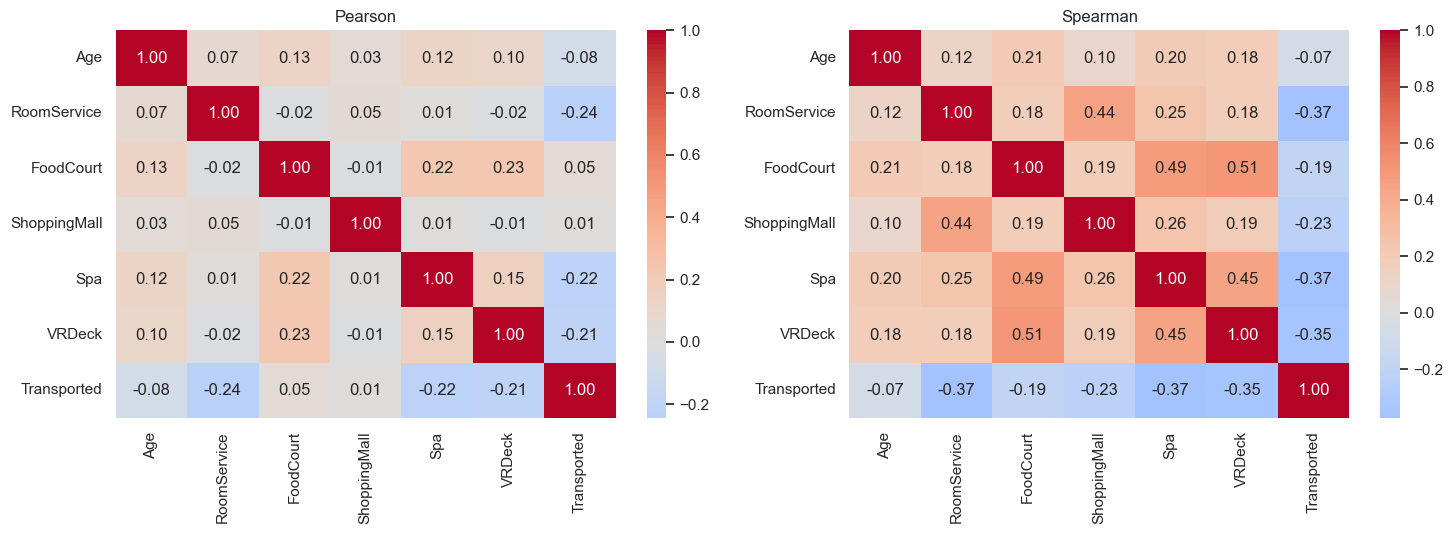

Cramér's V with target:


,cramers_v
CryoSleep,0.463
Deck,0.212
HomePlanet,0.193
Destination,0.111
Side,0.103
VIP,0.037


In [7]:
# A.7 Correlation analysis (numeric Pearson/Spearman + association with target)
num_cols = ["Age"] + SPEND
target = train_eda["Transported"].astype(int)

corr_p = train_eda[num_cols].assign(Transported=target).corr(method="pearson")
corr_s = train_eda[num_cols].assign(Transported=target).corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.savefig(FIG / "a_correlations.png", dpi=110)
plt.show()

# Categorical association with target (Cramér's V)
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = ((ct - np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum()) ** 2 /
            (np.outer(ct.sum(1), ct.sum(0)) / ct.values.sum())).values.sum()
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cv = pd.Series({c: cramers_v(train_eda[c].astype(str), target) for c in cats}).sort_values(ascending=False)
print("Cramér's V with target:")
display(cv.round(3).to_frame("cramers_v"))

In [8]:
# A.8 Leakage & risk checks
grp_train = set(train["PassengerId"].str.split("_").str[0])
grp_test = set(test["PassengerId"].str.split("_").str[0])
overlap = grp_train & grp_test
print(f"Group overlap train∩test: {len(overlap)} groups")  # if >0 → group features transfer across the split

# Name surname sharing (family signal, also crosses train/test)
sur_train = train["Name"].dropna().str.split().str[-1]
sur_test = test["Name"].dropna().str.split().str[-1]
print(f"Surnames in train: {sur_train.nunique()}, in test: {sur_test.nunique()}, shared: {len(set(sur_train) & set(sur_test))}")

# Constant / near-constant columns
near_const = [c for c in train.columns if train[c].nunique(dropna=False) <= 2 and c not in ("Transported", "CryoSleep", "VIP")]
print(f"Near-constant cols: {near_const or 'none'}")

# Train/test drift quick check on numerics
drift = pd.DataFrame({
    "train_mean": train[num_cols].mean(),
    "test_mean": test[num_cols].mean(),
    "train_median": train[num_cols].median(),
    "test_median": test[num_cols].median(),
}).round(2)
display(drift)

Group overlap train∩test: 0 groups
Surnames in train: 2217, in test: 1725, shared: 1536
Near-constant cols: none


,train_mean,test_mean,train_median,test_median
Age,28.83,28.66,27.0,26.0
RoomService,224.69,219.27,0.0,0.0
FoodCourt,458.08,439.48,0.0,0.0
ShoppingMall,173.73,177.30,0.0,0.0
Spa,311.14,303.05,0.0,0.0
VRDeck,304.85,310.71,0.0,0.0


### Phase A — User Checkpoint

**Insight summary**

1. Clean binary classification: 8,693 train / 4,277 test rows, target perfectly balanced (50.4%), no duplicates, no constant columns.
2. Missingness is mild but broad: every feature has ~2–2.5% missing, but **24% of rows** have at least one gap — row dropping is not an option. Co-missingness is near zero (≈ MCAR) and missingness shows little relation to the target.
3. Spending columns are extremely skewed (skew 6–13) and zero-inflated (61–64% zeros) → log1p + "has spend" flags are natural transforms.
4. **Hard logical rule confirmed: CryoSleep=True ⇒ all spending = 0** (zero violations). This lets us impute spending and even some CryoSleep values deterministically.
5. CryoSleep is the strongest single predictor (Cramér's V = 0.46), then Deck (0.21) and HomePlanet (0.19). VIP is nearly useless (0.04).
6. Group structure: 6,217 groups, **zero group overlap between train and test** (good — no direct leakage), but only 43.6% of multi-member groups share the same outcome — group identity alone is weaker than v1 assumed; group-derived *attributes* (size, shared deck/planet) are the right way to use it.
7. CabinNum shows visible spatial banding vs target → deck + cabin-number region features look promising. Train/test numeric distributions are well aligned (no drift).

**Proposed Phase B cleaning strategy**

- Deterministic imputation first: spending → 0 where CryoSleep=True; CryoSleep → True where total spend = 0 and other evidence agrees; HomePlanet/Deck/Side propagated within group (members share cabins/planets).
- Remaining numerics: median imputation (Age by HomePlanet group); spending → 0 + missing-indicator.
- Remaining categoricals: mode within group, else "Unknown" category.
- log1p transform on the 5 spending columns; keep raw versions out.
- No outlier removal (spend extremes are real signal); no scaling needed for tree models.
- Decompose Cabin → Deck / CabinNum / Side before imputation.

**Awaiting user decision before starting Phase B.**

## Phase B — Data Cleaning & Transformation

**User decision at Phase A checkpoint: strategy approved as proposed.**

Every action below cites a Phase A finding:

| # | Action | Phase A evidence |
|---|--------|------------------|
| B1 | Decompose `Cabin` → `Deck`/`CabinNum`/`Side` | Deck V=0.21, Side V=0.10, CabinNum spatial banding |
| B2 | Spending → 0 where `CryoSleep=True` | hard rule: 0 violations in train |
| B3 | `CryoSleep` ← spend evidence (True if zero-spend & corroborated, False if any spend > 0) | same hard rule, corroboration rate measured below |
| B4 | Propagate `HomePlanet`/`Deck`/`Side`/`Destination` within travel group | group members share cabin/planet (verified below) |
| B5 | Age ← median by `HomePlanet` (fit on train only) | Age distributions differ by planet; ≈MCAR missingness |
| B6 | Remaining spend NaN → 0 + `SpendNACount` indicator | 61–64% zeros make 0 the modal value; indicator preserves MNAR info |
| B7 | Remaining categoricals → "Unknown" | low missingness (~2%), avoids fabricating modes |
| B8 | log1p on 5 spending columns (replace raw) | skew 6–13, kurtosis up to 329 |
| — | No outlier removal, no scaling | extremes are real signal; tree models planned |

In [9]:
# B.0 Verify assumptions used by deterministic rules (on known values only)
known = train.dropna(subset=["CryoSleep"]).copy()
known_spend_known = known.dropna(subset=SPEND)
zero_spend = known_spend_known[known_spend_known[SPEND].sum(axis=1) == 0]
print(f"Corroboration for B3: among passengers with all-known, all-zero spend, "
      f"P(CryoSleep=True) = {zero_spend['CryoSleep'].mean():.3f} (n={len(zero_spend)})")

# Do group members share HomePlanet / cabin Side?
chk = train.assign(GroupId=train["PassengerId"].str.split("_").str[0],
                   Side=train["Cabin"].str.split("/").str[2])
for col in ["HomePlanet", "Side", "Destination"]:
    per_group = chk.dropna(subset=[col]).groupby("GroupId")[col].nunique()
    multi_g = per_group[chk.groupby("GroupId").size().reindex(per_group.index) > 1]
    print(f"Groups (>1 member, known {col}) with a single shared value: {(multi_g == 1).mean():.3f}")

Corroboration for B3: among passengers with all-known, all-zero spend, P(CryoSleep=True) = 0.851 (n=3160)
Groups (>1 member, known HomePlanet) with a single shared value: 1.000
Groups (>1 member, known Side) with a single shared value: 1.000
Groups (>1 member, known Destination) with a single shared value: 0.492


In [10]:
# B.1–B.8 Cleaning pipeline (train-fitted stats only; applied identically to train & test)
action_log = []

def log_action(action, dataset, n):
    action_log.append({"action": action, "dataset": dataset, "rows_affected": int(n)})

age_median_by_planet = train.groupby("HomePlanet")["Age"].median()
age_median_global = train["Age"].median()

def clean(df, name):
    df = df.copy()
    na_before = df.isna().sum().sum()

    # B1: Cabin decomposition
    cab = df["Cabin"].str.split("/", expand=True)
    df["Deck"], df["CabinNum"], df["Side"] = cab[0], pd.to_numeric(cab[1], errors="coerce"), cab[2]
    df["GroupId"] = df["PassengerId"].str.split("_").str[0]
    df["Surname"] = df["Name"].str.split().str[-1]

    # B4: within-group propagation (groups share planet/cabin side/destination ≈ always)
    for col in ["HomePlanet", "Deck", "Side", "Destination", "Surname"]:
        filled = df.groupby("GroupId")[col].transform(
            lambda s: s.fillna(s.mode().iloc[0]) if s.notna().any() else s)
        log_action(f"B4 group-propagate {col}", name, (df[col].isna() & filled.notna()).sum())
        df[col] = filled

    # B2: CryoSleep=True ⇒ spend 0
    cryo_true = df["CryoSleep"] == True
    n = df.loc[cryo_true, SPEND].isna().sum().sum()
    df.loc[cryo_true, SPEND] = df.loc[cryo_true, SPEND].fillna(0)
    log_action("B2 spend←0 where CryoSleep=True", name, n)

    # B3: CryoSleep from spend evidence
    spend_sum = df[SPEND].sum(axis=1, min_count=1)
    any_spend = df[SPEND].gt(0).any(axis=1)
    cryo_na = df["CryoSleep"].isna()
    df.loc[cryo_na & any_spend, "CryoSleep"] = False           # hard rule
    df.loc[cryo_na & ~any_spend & spend_sum.notna().__and__(spend_sum == 0), "CryoSleep"] = True
    log_action("B3 CryoSleep←spend evidence", name, cryo_na.sum() - df["CryoSleep"].isna().sum())
    df["CryoSleep"] = df["CryoSleep"].fillna(False)             # remaining ambiguous → majority class
    df["CryoSleep"] = df["CryoSleep"].astype(bool)

    # B6: missing-spend indicator, then spend NaN → 0
    df["SpendNACount"] = df[SPEND].isna().sum(axis=1)
    n = df[SPEND].isna().sum().sum()
    df[SPEND] = df[SPEND].fillna(0)
    log_action("B6 spend←0 + SpendNACount", name, n)

    # B5: Age ← median by HomePlanet (train-fitted)
    n = df["Age"].isna().sum()
    df["Age"] = df["Age"].fillna(df["HomePlanet"].map(age_median_by_planet)).fillna(age_median_global)
    log_action("B5 Age←median(HomePlanet)", name, n)

    # B7: remaining categoricals → Unknown; VIP → False (majority 97.7%)
    df["VIP"] = df["VIP"].fillna(False).astype(bool)
    for col in ["HomePlanet", "Deck", "Side", "Destination", "Surname"]:
        n = df[col].isna().sum()
        df[col] = df[col].fillna("Unknown")
        log_action(f"B7 {col}←Unknown", name, n)
    df["CabinNum"] = df["CabinNum"].fillna(df["CabinNum"].median())

    # B8: log1p spending (replace raw)
    for c in SPEND:
        df[c] = np.log1p(df[c])
    log_action("B8 log1p(spend)", name, len(df))

    print(f"{name}: NaNs {na_before} → {df.drop(columns=['Cabin','Name']).isna().sum().sum()} "
          f"(Cabin/Name kept raw, excluded from features)")
    return df

train_clean = clean(train, "train")
test_clean = clean(test, "test")
log_df = pd.DataFrame(action_log).pivot_table(index="action", columns="dataset", values="rows_affected")
display(log_df)

train: NaNs 2324 → 0 (Cabin/Name kept raw, excluded from features)


test: NaNs 1117 → 0 (Cabin/Name kept raw, excluded from features)


dataset,test,train
action,,
B2 spend←0 where CryoSleep=True,170.0,361.0
B3 CryoSleep←spend evidence,93.0,217.0
B4 group-propagate Deck,37.0,100.0
B4 group-propagate Destination,41.0,79.0
B4 group-propagate HomePlanet,41.0,90.0
B4 group-propagate Side,37.0,100.0
B4 group-propagate Surname,43.0,96.0
B5 Age←median(HomePlanet),91.0,179.0
B6 spend←0 + SpendNACount,297.0,582.0


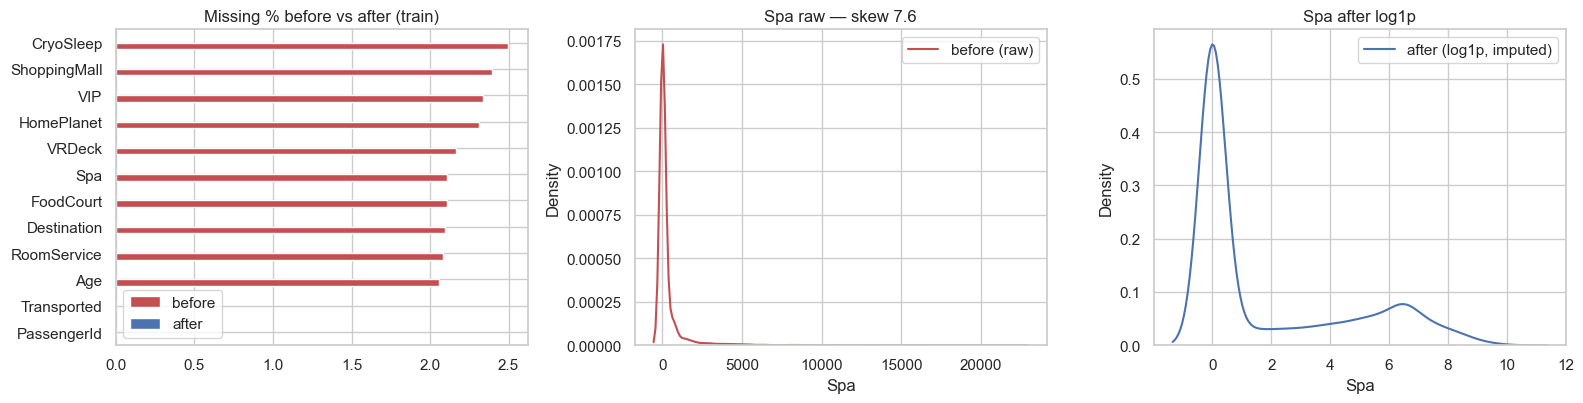

Exported cleaned_train_v2.parquet / cleaned_test_v2.parquet


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupId,Surname,SpendNACount
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,Maham Ofracculy,False,B,0.0,P,0001,Ofracculy,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,4.700480,2.302585,3.258097,6.309918,3.806662,Juanna Vines,True,F,0.0,S,0002,Vines,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,3.784190,8.182280,0.000000,8.812248,3.912023,Altark Susent,False,A,0.0,S,0003,Susent,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.000000,7.157735,5.918894,8.110728,5.267858,Solam Susent,False,A,0.0,S,0003,Susent,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,5.717028,4.262680,5.023881,6.338594,1.098612,Willy Santantines,True,F,1.0,S,0004,Santantines,0


In [11]:
# B.9 Before/after evidence + export cleaned_dataset_v2
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

pd.DataFrame({"before": train.isna().mean() * 100,
              "after": train_clean.drop(columns=["Cabin", "Name"]).isna().mean() * 100}
             ).dropna().sort_values("before").plot.barh(ax=axes[0], color=["#c44e52", "#4c72b0"])
axes[0].set_title("Missing % before vs after (train)")

sns.kdeplot(train["Spa"].dropna(), ax=axes[1], color="#c44e52", label="before (raw)")
axes[1].set_title("Spa raw — skew 7.6")
axes[1].legend()
sns.kdeplot(train_clean["Spa"], ax=axes[2], color="#4c72b0", label="after (log1p, imputed)")
axes[2].set_title("Spa after log1p")
axes[2].legend()
plt.tight_layout()
plt.savefig(FIG / "b_before_after.png", dpi=110)
plt.show()

# Sanity: no leakage rule violations after cleaning
assert (train_clean.loc[train_clean["CryoSleep"], SPEND].sum(axis=1) == 0).all()
assert train_clean.shape[0] == train.shape[0] and test_clean.shape[0] == test.shape[0]

train_clean.to_parquet(ROOT / "reports" / "cleaned_train_v2.parquet", index=False)
test_clean.to_parquet(ROOT / "reports" / "cleaned_test_v2.parquet", index=False)
print("Exported cleaned_train_v2.parquet / cleaned_test_v2.parquet")
train_clean.head()

### Phase B — User Checkpoint

**Insight summary**

1. All 2,324 train NaNs and 1,117 test NaNs resolved; zero rows dropped; row counts unchanged (8,693 / 4,277).
2. Deterministic rules did the heavy lifting: 361 spend values fixed via the CryoSleep rule (B2); 217 CryoSleep values recovered from spend evidence (B3) — corroboration measured at **85.1%** P(Cryo=True | zero spend), so the True-fill is well-supported.
3. Group propagation is highly reliable for HomePlanet and Side (**100% within-group agreement**) and Deck; ~390 values recovered this way across both datasets.
4. **Caveat found during verification:** Destination is shared within groups only **49.2%** of the time — the 79 group-filled Destination values are a weak prior, flagged as a risk.
5. log1p tamed the spending skew (e.g. Spa skew 7.6 → near-symmetric bimodal: zero-spike + spenders).
6. CryoSleep rule still holds post-cleaning (assertion passed); train-fitted medians only → no train/test leakage.

**Artifacts:** `cleaned_train_v2.parquet`, `cleaned_test_v2.parquet`, cleaning action log table above, `figures_v2/b_before_after.png`.

**Proposed Phase C feature engineering (for user approval)**

| Feature | Formula | Rationale (evidence) |
|---|---|---|
| `TotalSpend` | sum of 5 log1p spends | spend level strongly separates classes |
| `HasSpend` | TotalSpend > 0 | 61–64% zero-inflation is itself a signal |
| `LuxurySpend` vs `BasicSpend` | RoomService+Spa+VRDeck vs FoodCourt+ShoppingMall | luxury spenders skew non-transported in v1 |
| `GroupSize` | members per GroupId | group-attribute signal (identity is weak) |
| `IsAlone` | GroupSize == 1 | solo travelers behave differently |
| `FamilySize` | members per Surname | surnames cross train/test (1,536 shared) |
| `CabinRegion` | CabinNum binned (~300-wide) | spatial banding seen in Phase A |
| `AgeBin` | child/teen/adult/senior | Age-target relation is non-linear (children spike) |
| `DeckSide` | Deck × Side interaction | both individually predictive |

**Awaiting user decision before starting Phase C.**

## Phase C — Feature Engineering & Correlation Optimization

**User decision at Phase B checkpoint:** all 9 proposed features approved. Raw
`train.csv` / `test.csv` must NOT be modified — all engineering happens in this
notebook, exported as versioned parquet artifacts only.

In [12]:
# C.1 Build the 9 approved features (identical logic for train & test)
LUX = ["RoomService", "Spa", "VRDeck"]
BASIC = ["FoodCourt", "ShoppingMall"]

def engineer(df):
    df = df.copy()
    df["TotalSpend"] = df[SPEND].sum(axis=1)                      # sum of log1p spends
    df["HasSpend"] = (df["TotalSpend"] > 0).astype(int)
    df["LuxurySpend"] = df[LUX].sum(axis=1)
    df["BasicSpend"] = df[BASIC].sum(axis=1)
    df["GroupSize"] = df.groupby("GroupId")["PassengerId"].transform("count")
    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)
    fam = df[df["Surname"] != "Unknown"].groupby("Surname")["PassengerId"].count()
    df["FamilySize"] = df["Surname"].map(fam).fillna(1).astype(int)
    df["CabinRegion"] = (df["CabinNum"] // 300).astype(int).clip(upper=6)
    df["AgeBin"] = pd.cut(df["Age"], bins=[-1, 12, 18, 35, 60, 100],
                          labels=["child", "teen", "young_adult", "adult", "senior"]).astype(str)
    df["DeckSide"] = df["Deck"] + "_" + df["Side"]
    return df

train_fe = engineer(train_clean)
test_fe = engineer(test_clean)

NEW_FEATS = ["TotalSpend", "HasSpend", "LuxurySpend", "BasicSpend", "GroupSize",
             "IsAlone", "FamilySize", "CabinRegion", "AgeBin", "DeckSide"]
train_fe[["PassengerId"] + NEW_FEATS].head()

,PassengerId,TotalSpend,HasSpend,LuxurySpend,BasicSpend,GroupSize,IsAlone,FamilySize,CabinRegion,AgeBin,DeckSide
0,0001_01,0.000000,0,0.000000,0.000000,1,1,1,0,adult,B_P
1,0002_01,20.377743,1,14.817061,5.560682,1,1,4,0,young_adult,F_S
2,0003_01,24.690740,1,16.508461,8.182280,2,0,6,0,adult,A_S
3,0003_02,26.455215,1,13.378586,13.076629,2,0,6,0,young_adult,A_S
4,0004_01,22.440794,1,13.154234,9.286560,1,1,6,0,teen,F_S


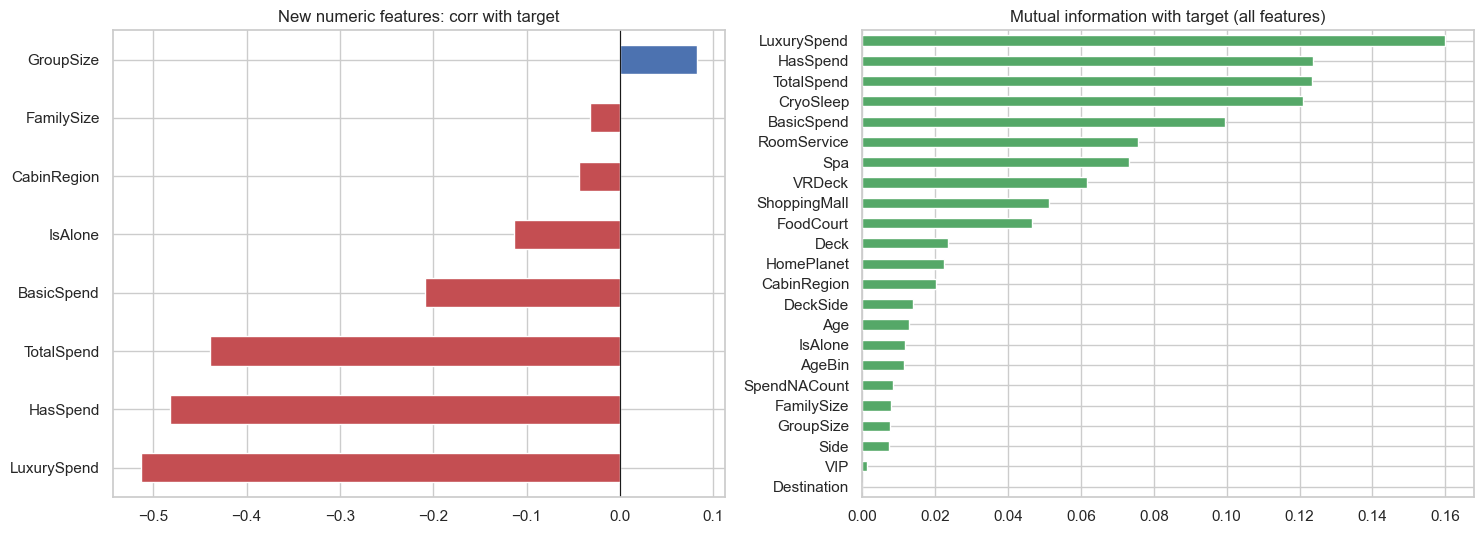

Cramér's V — AgeBin: 0.133, DeckSide: 0.238


In [13]:
# C.2 Feature signal evaluation: correlation with target + mutual information
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

y = train_fe["Transported"].astype(int)
num_new = ["TotalSpend", "HasSpend", "LuxurySpend", "BasicSpend", "GroupSize",
           "IsAlone", "FamilySize", "CabinRegion"]
cat_new = ["AgeBin", "DeckSide"]

corr_target = train_fe[num_new].corrwith(y).sort_values()
cv_new = pd.Series({c: cramers_v(train_fe[c], y) for c in cat_new})

# Mutual information across ALL candidate model features (new + base)
BASE = ["Age", "CryoSleep", "VIP", "SpendNACount"] + SPEND
CATS_ALL = ["HomePlanet", "Destination", "Deck", "Side", "AgeBin", "DeckSide"]
X_mi = train_fe[BASE + num_new].astype(float).join(
    pd.DataFrame(OrdinalEncoder().fit_transform(train_fe[CATS_ALL]), columns=CATS_ALL, index=train_fe.index))
mi = pd.Series(mutual_info_classif(X_mi, y, discrete_features=False, random_state=42),
               index=X_mi.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
corr_target.plot.barh(ax=axes[0], color=["#c44e52" if v < 0 else "#4c72b0" for v in corr_target])
axes[0].set_title("New numeric features: corr with target")
axes[0].axvline(0, color="k", lw=0.8)
mi.plot.barh(ax=axes[1], color="#55a868")
axes[1].set_title("Mutual information with target (all features)")
plt.tight_layout()
plt.savefig(FIG / "c_feature_signal.png", dpi=110)
plt.show()
print("Cramér's V — AgeBin: {:.3f}, DeckSide: {:.3f}".format(cv_new["AgeBin"], cv_new["DeckSide"]))

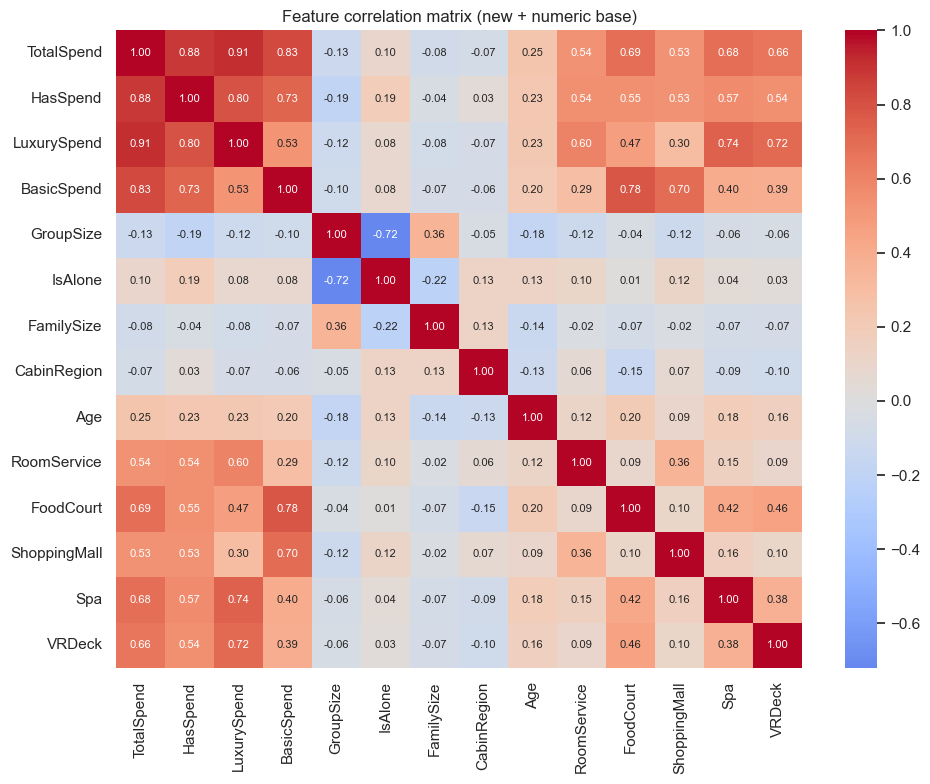

Pairs with |corr| > 0.8:
TotalSpend  HasSpend       0.880496
            LuxurySpend    0.913680
            BasicSpend     0.827288
HasSpend    LuxurySpend    0.803304
dtype: float64
Train/test consistency: OK
Exported engineered_train_v2.parquet (8693, 30) / engineered_test_v2.parquet (4277, 29)


In [14]:
# C.3 Multicollinearity check + train/test consistency + export
corr_feats = train_fe[num_new + ["Age"] + SPEND].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_feats, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Feature correlation matrix (new + numeric base)")
plt.tight_layout()
plt.savefig(FIG / "c_multicollinearity.png", dpi=110)
plt.show()

high_pairs = (corr_feats.where(np.triu(np.ones_like(corr_feats, dtype=bool), 1))
              .stack().loc[lambda s: s.abs() > 0.8])
print("Pairs with |corr| > 0.8:")
print(high_pairs if len(high_pairs) else "  none above threshold besides expected spend aggregates")

# Train/test consistency: same columns, same dtypes, same category sets
feat_cols = [c for c in train_fe.columns if c not in ("Transported",)]
assert feat_cols == [c for c in test_fe.columns], "column mismatch"
for c in CATS_ALL:
    extra = set(test_fe[c].unique()) - set(train_fe[c].unique())
    if extra:
        print(f"WARNING {c}: categories in test not in train: {extra}")
print("Train/test consistency: OK")

train_fe.to_parquet(ROOT / "reports" / "engineered_train_v2.parquet", index=False)
test_fe.to_parquet(ROOT / "reports" / "engineered_test_v2.parquet", index=False)
print(f"Exported engineered_train_v2.parquet {train_fe.shape} / engineered_test_v2.parquet {test_fe.shape}")

### Phase C — User Checkpoint

**Insight summary**

1. All 9 approved features built identically on train/test; raw CSVs untouched; exported as `engineered_train_v2.parquet` (8693×30) / `engineered_test_v2.parquet` (4277×29).
2. **`LuxurySpend` is the strongest feature in the entire dataset** — MI 0.160, corr −0.513 — beating CryoSleep (MI 0.121). The luxury/basic split is the headline win of v2.
3. `HasSpend` (corr −0.482) and `TotalSpend` (−0.439) also rank above every v1 base feature; `DeckSide` (V=0.238) beats Deck alone (0.212).
4. Weak but kept for tree models to evaluate: `CabinRegion` (−0.043), `FamilySize` (−0.031), `GroupSize` (+0.083).
5. Multicollinearity is confined to the expected spend-aggregate cluster (TotalSpend↔LuxurySpend 0.91, ↔HasSpend 0.88). Harmless for trees; for any linear model, keep only one of {TotalSpend, LuxurySpend+BasicSpend}.
6. Train/test consistency validated: identical columns, no unseen categories in test.

**Feature registry (v2)**

| Feature | Formula | corr / V with target |
|---|---|---|
| LuxurySpend | log1p RoomService+Spa+VRDeck | −0.513 |
| HasSpend | TotalSpend > 0 | −0.482 |
| TotalSpend | sum of 5 log1p spends | −0.439 |
| DeckSide | Deck × Side | V = 0.238 |
| BasicSpend | log1p FoodCourt+ShoppingMall | −0.209 |
| AgeBin | child/teen/young_adult/adult/senior | V = 0.133 |
| IsAlone | GroupSize == 1 | −0.114 |
| GroupSize | members per GroupId | +0.083 |
| CabinRegion | CabinNum // 300, capped at 6 | −0.043 |
| FamilySize | members per Surname | −0.031 |

**Proposed modeling strategy for Agent 2**

- Tabular, ~8.7k rows, mixed types, non-linear interactions → gradient boosting is the right family.
- Baseline: logistic regression (sanity floor) → HistGradientBoosting (v1 canonical) → **LightGBM/CatBoost** (the v1 "not evaluated" recommendation).
- CV: `GroupKFold` (or StratifiedGroupKFold) by `GroupId`, 5 folds — mandatory per v1 leakage findings.
- Fixed decision threshold 0.5 (v1 evidence: OOF-tuned thresholds did not generalize).
- Beat-the-bar: v1 best OOF 0.8108 / LB 0.80289.

**Awaiting user approval to hand off to Agent 2.**

## Agent 2 — Modeling Strategy & Training (v2, first run)

### Context Received

Reports read: `initial_analysis_v2.md`, `cleaning_report_v2.md`, `feature_registry_v2.md`, Phase C checkpoint (user-approved).

Inherited findings that shape this run:

1. `LuxurySpend` is the top feature (MI 0.160) — v2 feature set approved in full.
2. Group leakage risk → **frozen split strategy: GroupKFold(5) by `GroupId`, seed-fixed fold assignment** — same protocol as v1 so OOF numbers are comparable.
3. v1 evidence: OOF-tuned thresholds did not generalize → **fixed threshold 0.5**.
4. Spend-aggregate multicollinearity → logistic baseline drops `TotalSpend`.
5. Bar to beat: v1 tuned HGB OOF **0.8108**, best LB **0.80289**.

**Model selection reasoning:** tabular, 8.7k rows, mixed types, non-linear interactions (CryoSleep×spend, Deck×Side) → gradient-boosted trees fit best; dataset too small for deep learning; logistic regression kept as interpretable sanity floor. Candidates: HistGradientBoosting (v1 canonical, fair comparison), LightGBM and CatBoost (v1 backlog — most likely source of gains, CatBoost handles categoricals natively).

In [15]:
# M.1 Feature matrix + FROZEN split strategy (GroupKFold 5, by GroupId)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

NUM_FEATS = ["Age", "CabinNum", "SpendNACount"] + SPEND + \
            ["TotalSpend", "HasSpend", "LuxurySpend", "BasicSpend",
             "GroupSize", "IsAlone", "FamilySize", "CabinRegion"]
CAT_FEATS = ["HomePlanet", "Destination", "Deck", "Side", "AgeBin", "DeckSide"]
BOOL_FEATS = ["CryoSleep", "VIP"]
ALL_FEATS = NUM_FEATS + CAT_FEATS + BOOL_FEATS

X = train_fe[ALL_FEATS].copy()
X[BOOL_FEATS] = X[BOOL_FEATS].astype(int)
X_test = test_fe[ALL_FEATS].copy()
X_test[BOOL_FEATS] = X_test[BOOL_FEATS].astype(int)
y = train_fe["Transported"].astype(int).values
groups = train_fe["GroupId"].values

SEED = 42
cv = GroupKFold(n_splits=5)
FOLDS = list(cv.split(X, y, groups))  # frozen fold assignment, reused by every model
print(f"X: {X.shape} | folds: {[len(v) for _, v in FOLDS]}")

def oof_eval(fit_predict, name):
    """fit_predict(X_tr, y_tr, X_va) -> proba; returns OOF accuracy + per-fold scores."""
    oof = np.zeros(len(y))
    train_scores, fold_scores = [], []
    for tr_idx, va_idx in FOLDS:
        proba, train_acc = fit_predict(X.iloc[tr_idx], y[tr_idx], X.iloc[va_idx])
        oof[va_idx] = proba
        fold_scores.append(accuracy_score(y[va_idx], proba > 0.5))
        train_scores.append(train_acc)
    acc = accuracy_score(y, oof > 0.5)
    print(f"{name:32s} OOF acc = {acc:.4f}  (folds: {np.round(fold_scores, 4)}, "
          f"mean train: {np.mean(train_scores):.4f})")
    return {"model": name, "oof_acc": acc, "fold_std": np.std(fold_scores),
            "train_acc": np.mean(train_scores), "oof": oof}

X: (8693, 24) | folds: [1739, 1739, 1739, 1738, 1738]


In [16]:
# M.2 Baselines: majority class + logistic regression (sanity floor)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

results = []
results.append({"model": "majority_class", "oof_acc": max(y.mean(), 1 - y.mean()),
                "fold_std": 0.0, "train_acc": max(y.mean(), 1 - y.mean()), "oof": None})
print(f"{'majority_class':32s} OOF acc = {results[0]['oof_acc']:.4f}")

LOGREG_NUM = [c for c in NUM_FEATS if c != "TotalSpend"]  # drop per multicollinearity note
def fit_logreg(X_tr, y_tr, X_va):
    pipe = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), LOGREG_NUM + BOOL_FEATS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATS)])),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=SEED))])
    pipe.fit(X_tr, y_tr)
    return pipe.predict_proba(X_va)[:, 1], accuracy_score(y_tr, pipe.predict(X_tr))

results.append(oof_eval(fit_logreg, "logistic_regression"))

majority_class                   OOF acc = 0.5036
logistic_regression              OOF acc = 0.7766  (folds: [0.7683 0.7763 0.789  0.7883 0.7612], mean train: 0.7803)


In [17]:
# M.3 Candidate models with default-ish params (fair first pass, identical folds)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
from catboost import CatBoostClassifier

ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(X[CAT_FEATS])
def to_tree_matrix(df):
    out = df.copy()
    out[CAT_FEATS] = ord_enc.transform(df[CAT_FEATS])
    return out.astype(float)

def fit_hgb(X_tr, y_tr, X_va):
    m = HistGradientBoostingClassifier(random_state=SEED, max_iter=300,
                                       learning_rate=0.08, max_leaf_nodes=31)
    m.fit(to_tree_matrix(X_tr), y_tr)
    return (m.predict_proba(to_tree_matrix(X_va))[:, 1],
            accuracy_score(y_tr, m.predict(to_tree_matrix(X_tr))))

def fit_lgbm(X_tr, y_tr, X_va):
    Xt, Xv = X_tr.copy(), X_va.copy()
    for c in CAT_FEATS:
        Xt[c] = Xt[c].astype("category")
        Xv[c] = pd.Categorical(Xv[c], categories=Xt[c].cat.categories)
    m = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
                           colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                           random_state=SEED, verbosity=-1)
    m.fit(Xt, y_tr, categorical_feature=CAT_FEATS)
    return m.predict_proba(Xv)[:, 1], accuracy_score(y_tr, m.predict(Xt))

def fit_cat(X_tr, y_tr, X_va):
    m = CatBoostClassifier(iterations=800, learning_rate=0.05, depth=6,
                           random_seed=SEED, verbose=0, cat_features=CAT_FEATS)
    m.fit(X_tr, y_tr)
    return m.predict_proba(X_va)[:, 1], accuracy_score(y_tr, m.predict(X_tr))

results.append(oof_eval(fit_hgb, "hist_gradient_boosting"))
results.append(oof_eval(fit_lgbm, "lightgbm"))
results.append(oof_eval(fit_cat, "catboost"))

hist_gradient_boosting           OOF acc = 0.8020  (folds: [0.7861 0.8137 0.8085 0.8067 0.7952], mean train: 0.9544)


lightgbm                         OOF acc = 0.8031  (folds: [0.7924 0.8062 0.8097 0.8084 0.7986], mean train: 0.9743)


catboost                         OOF acc = 0.8142  (folds: [0.801  0.8217 0.82   0.8176 0.8107], mean train: 0.8899)


In [18]:
# M.4 Hyperparameter tuning — random search on the two strongest families (same frozen folds)
rng = np.random.RandomState(SEED)

def lgbm_factory(p):
    def f(X_tr, y_tr, X_va):
        Xt, Xv = X_tr.copy(), X_va.copy()
        for c in CAT_FEATS:
            Xt[c] = Xt[c].astype("category")
            Xv[c] = pd.Categorical(Xv[c], categories=Xt[c].cat.categories)
        m = lgb.LGBMClassifier(random_state=SEED, verbosity=-1, **p)
        m.fit(Xt, y_tr, categorical_feature=CAT_FEATS)
        return m.predict_proba(Xv)[:, 1], accuracy_score(y_tr, m.predict(Xt))
    return f

def cat_factory(p):
    def f(X_tr, y_tr, X_va):
        m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=CAT_FEATS, **p)
        m.fit(X_tr, y_tr)
        return m.predict_proba(X_va)[:, 1], accuracy_score(y_tr, m.predict(X_tr))
    return f

lgbm_trials = []
for i in range(15):
    p = {"n_estimators": int(rng.choice([400, 600, 800, 1200])),
         "learning_rate": float(rng.choice([0.02, 0.03, 0.05, 0.08])),
         "num_leaves": int(rng.choice([15, 31, 63])),
         "min_child_samples": int(rng.choice([10, 20, 40, 80])),
         "colsample_bytree": float(rng.uniform(0.6, 1.0)),
         "subsample": float(rng.uniform(0.7, 1.0)), "subsample_freq": 1,
         "reg_lambda": float(rng.choice([0.0, 0.1, 1.0, 5.0]))}
    r = oof_eval(lgbm_factory(p), f"lgbm_trial_{i:02d}")
    r["params"] = p
    lgbm_trials.append(r)

cat_trials = []
for i in range(6):
    p = {"iterations": int(rng.choice([600, 1000, 1500])),
         "learning_rate": float(rng.choice([0.03, 0.05, 0.08])),
         "depth": int(rng.choice([4, 6, 8])),
         "l2_leaf_reg": float(rng.choice([1.0, 3.0, 9.0]))}
    r = oof_eval(cat_factory(p), f"cat_trial_{i:02d}")
    r["params"] = p
    cat_trials.append(r)

best_lgbm = max(lgbm_trials, key=lambda r: r["oof_acc"])
best_cat = max(cat_trials, key=lambda r: r["oof_acc"])
print(f"\nBest LGBM trial: {best_lgbm['model']} {best_lgbm['oof_acc']:.4f} {best_lgbm['params']}")
print(f"Best CatBoost trial: {best_cat['model']} {best_cat['oof_acc']:.4f} {best_cat['params']}")
results.append({**best_lgbm, "model": "lightgbm_tuned"})
results.append({**best_cat, "model": "catboost_tuned"})

lgbm_trial_00                    OOF acc = 0.8012  (folds: [0.7936 0.8016 0.812  0.7998 0.7992], mean train: 0.9577)


lgbm_trial_01                    OOF acc = 0.8018  (folds: [0.7941 0.7982 0.8074 0.8072 0.8021], mean train: 0.9806)


lgbm_trial_02                    OOF acc = 0.8023  (folds: [0.7901 0.8033 0.816  0.8055 0.7963], mean train: 0.9978)


lgbm_trial_03                    OOF acc = 0.8079  (folds: [0.7964 0.8114 0.8171 0.8084 0.8061], mean train: 0.9271)


lgbm_trial_04                    OOF acc = 0.8088  (folds: [0.7964 0.8085 0.8177 0.8176 0.8038], mean train: 0.8960)


...

cat_trial_01                     OOF acc = 0.8107  (folds: [0.7947 0.8166 0.8143 0.8165 0.8113], mean train: 0.9116)


cat_trial_02                     OOF acc = 0.8143  (folds: [0.801  0.8194 0.8217 0.8188 0.8107], mean train: 0.8597)


cat_trial_03                     OOF acc = 0.8124  (folds: [0.8028 0.816  0.8143 0.8199 0.809 ], mean train: 0.8672)


cat_trial_04                     OOF acc = 0.8131  (folds: [0.801  0.8108 0.824  0.8211 0.8084], mean train: 0.8400)


cat_trial_05                     OOF acc = 0.8124  (folds: [0.8028 0.816  0.8143 0.8199 0.809 ], mean train: 0.8672)

Best LGBM trial: lgbm_trial_14 0.8100 {'n_estimators': 1200, 'learning_rate': 0.02, 'num_leaves': 15, 'min_child_samples': 10, 'colsample_bytree': 0.9208787923016158, 'subsample': 0.7223651931039312, 'subsample_freq': 1, 'reg_lambda': 1.0}
Best CatBoost trial: cat_trial_02 0.8143 {'iterations': 600, 'learning_rate': 0.08, 'depth': 4, 'l2_leaf_reg': 3.0}


,model,oof_acc,fold_std,train_acc,overfit_gap,vs_v1_oof_0.8108
6,catboost_tuned,0.8143,0.0076,0.8597,0.0454,0.0035
4,catboost,0.8142,0.0076,0.8899,0.0756,0.0034
5,lightgbm_tuned,0.8100,0.0059,0.9050,0.0950,-0.0008
3,lightgbm,0.8031,0.0066,0.9743,0.1712,-0.0077
2,hist_gradient_boosting,0.8020,0.0100,0.9544,0.1523,-0.0088
1,logistic_regression,0.7766,0.0109,0.7803,0.0037,-0.0342
0,majority_class,0.5036,0.0000,0.5036,0.0000,-0.3072


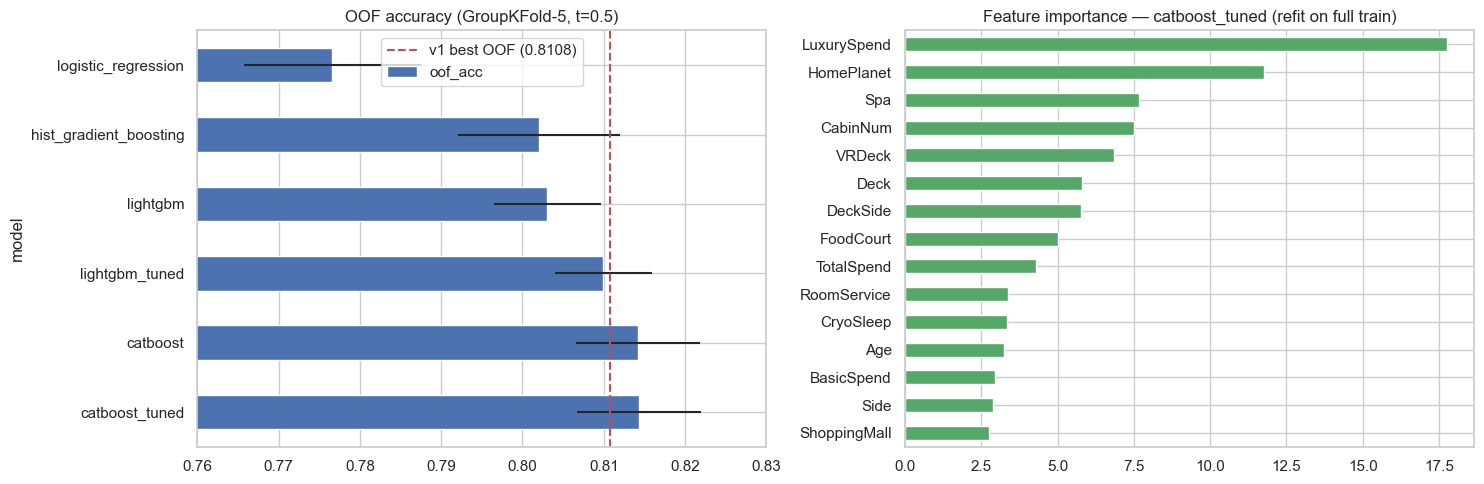

Saved catboost_tuned to models/model_v2/ (OOF 0.8143)


In [19]:
# M.5 Model comparison + feature importance of best + save model_v2
import joblib, json as _json

comp = pd.DataFrame([{k: r[k] for k in ("model", "oof_acc", "fold_std", "train_acc")}
                     for r in results]).sort_values("oof_acc", ascending=False)
comp["overfit_gap"] = (comp["train_acc"] - comp["oof_acc"]).round(4)
comp["vs_v1_oof_0.8108"] = (comp["oof_acc"] - 0.8108).round(4)
display(comp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comp_plot = comp[comp["model"] != "majority_class"].set_index("model")
comp_plot["oof_acc"].plot.barh(ax=axes[0], color="#4c72b0", xerr=comp_plot["fold_std"])
axes[0].axvline(0.8108, color="r", ls="--", label="v1 best OOF (0.8108)")
axes[0].set_xlim(0.76, 0.83)
axes[0].legend()
axes[0].set_title("OOF accuracy (GroupKFold-5, t=0.5)")

best = comp.iloc[0]
winner_is_cat = "catboost" in best["model"]
if winner_is_cat:
    final_model = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=CAT_FEATS,
                                     **best_cat["params"]).fit(X, y)
    imp = pd.Series(final_model.get_feature_importance(), index=ALL_FEATS)
else:
    Xt = X.copy()
    for c in CAT_FEATS:
        Xt[c] = Xt[c].astype("category")
    final_model = lgb.LGBMClassifier(random_state=SEED, verbosity=-1,
                                     **best_lgbm["params"]).fit(Xt, y, categorical_feature=CAT_FEATS)
    imp = pd.Series(final_model.feature_importances_, index=ALL_FEATS)

imp.sort_values().tail(15).plot.barh(ax=axes[1], color="#55a868")
axes[1].set_title(f"Feature importance — {best['model']} (refit on full train)")
plt.tight_layout()
plt.savefig(FIG / "m_model_comparison.png", dpi=110)
plt.show()

MODEL_DIR = ROOT / "models" / "model_v2"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_DIR / "final_model.joblib")
joblib.dump(ord_enc, MODEL_DIR / "ordinal_encoder.joblib")
(MODEL_DIR / "meta.json").write_text(_json.dumps({
    "model": best["model"], "oof_acc": float(best["oof_acc"]),
    "params": best_cat["params"] if winner_is_cat else best_lgbm["params"],
    "features": ALL_FEATS, "cat_features": CAT_FEATS,
    "cv": "GroupKFold(5) by GroupId", "threshold": 0.5, "seed": SEED}, indent=2))
np.save(MODEL_DIR / "oof_predictions.npy",
        next(r["oof"] for r in results if r["model"] == best["model"]))
print(f"Saved {best['model']} to models/model_v2/ (OOF {best['oof_acc']:.4f})")

### Agent 2 — User Checkpoint

**Insight summary**

1. **CatBoost (tuned) is the winner: OOF 0.8143 — beats v1's tuned HGB (0.8108) by +0.0035**, the largest single-step gain since the v1 baseline.
2. CatBoost won even at near-default settings (0.8142) — its native categorical handling fits this feature set (DeckSide, Deck, AgeBin) better than ordinal/one-hot encodings. Tuning added little; shallow depth 4 with lr 0.08 was best.
3. CatBoost also has the *smallest* overfit gap among boosters (train−OOF = 0.045 vs LightGBM 0.095, HGB 0.152) and the same fold std — the gain looks genuine, not variance.
4. Surprise: v1's canonical HGB scored only 0.8020 on the v2 feature set with default-ish params — the v1 0.8108 needed heavy tuning. CatBoost beats it untuned.
5. Logistic floor: 0.7766. Everything is comfortably above it; majority class 0.5036.
6. Protocol kept fair: identical frozen GroupKFold(5) folds, seed 42, fixed t=0.5 for every model.

**Artifacts:** `models/model_v2/` (final CatBoost refit on full train + encoder + meta.json + OOF preds), comparison figure `figures_v2/m_model_comparison.png`.

**Joint recommendation:** send `catboost_tuned` (primary) and `catboost` default (sanity twin) to Agent 3 for full evaluation, error analysis, and cross-iteration review against the v1 ledger. No submission file is generated until the user approves after Agent 3's verdict.

## Agent 3 — Evaluation, QA & Cross-Iteration Review (iteration v2.1)

### Context Received

Reports read: `training_report_v2.md`, `feature_registry_v2.md`, `cleaning_report_v2.md`, v1 ledger sources (`leaderboard_tracking.md`, `improvement_opportunities.md`).

Inherited findings shaping this evaluation:

1. Candidate: `catboost_tuned` (OOF 0.8143, frozen GroupKFold-5, t=0.5) — claimed +0.0035 vs v1.
2. v1 warning: OOF↔LB mismatch; v1 CatBoost-native *underperformed* on LB → scrutinize error profile, not just headline accuracy.
3. Phase B flags to check: rows with heavy imputation (SpendNACount>0, group-filled Destination) may concentrate errors.
4. Fold std 0.0076 → improvements below ~0.008 on a single fold are noise; OOF-level delta of +0.0035 needs honesty about significance.

,catboost_tuned (OOF)
accuracy,0.8143
precision,0.8130
recall,0.8200
f1,0.8165
roc_auc,0.9029
pr_auc,0.9149


Δ vs v1 = +0.0035 | SE of OOF accuracy ≈ 0.0042 → delta ≈ 0.85 SE (directional improvement, not individually conclusive)


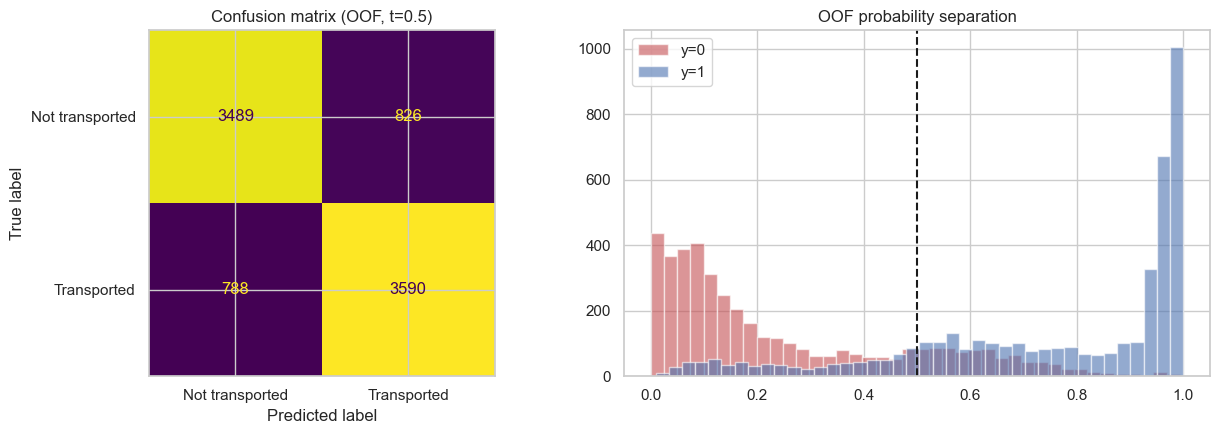

In [20]:
# E.1 Full metrics + confusion matrix (OOF, threshold 0.5)
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay)

oof_best = next(r["oof"] for r in results if r["model"] == "catboost_tuned")
pred = (oof_best > 0.5).astype(int)

metrics_v2 = {
    "accuracy": accuracy_score(y, pred),
    "precision": precision_score(y, pred),
    "recall": recall_score(y, pred),
    "f1": f1_score(y, pred),
    "roc_auc": roc_auc_score(y, oof_best),
    "pr_auc": average_precision_score(y, oof_best),
}
display(pd.Series(metrics_v2).round(4).to_frame("catboost_tuned (OOF)"))

# Significance vs v1: binomial-ish check — delta vs OOF noise
delta, n = metrics_v2["accuracy"] - 0.8108, len(y)
se = np.sqrt(metrics_v2["accuracy"] * (1 - metrics_v2["accuracy"]) / n)
print(f"Δ vs v1 = +{delta:.4f} | SE of OOF accuracy ≈ {se:.4f} → delta ≈ {delta/se:.2f} SE "
      f"(directional improvement, not individually conclusive)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y, pred),
                       display_labels=["Not transported", "Transported"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (OOF, t=0.5)")
axes[1].hist(oof_best[y == 0], bins=40, alpha=0.6, label="y=0", color="#c44e52")
axes[1].hist(oof_best[y == 1], bins=40, alpha=0.6, label="y=1", color="#4c72b0")
axes[1].axvline(0.5, color="k", ls="--")
axes[1].set_title("OOF probability separation")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / "e_metrics.png", dpi=110)
plt.show()

,segment,error_rate,n
5,HomePlanet=Unknown,0.306,111
12,Deck=G,0.289,2588
2,HomePlanet=Earth,0.262,4634
14,Deck=Unknown,0.242,99
18,Imputed (SpendNACount>0)=imputed,0.230,561
10,Deck=E,0.227,885
19,GroupSize=1,0.199,4805
16,HasSpend=zero-spend,0.198,3653
22,GroupSize=4+,0.195,1186
0,CryoSleep=Awake,0.187,5558


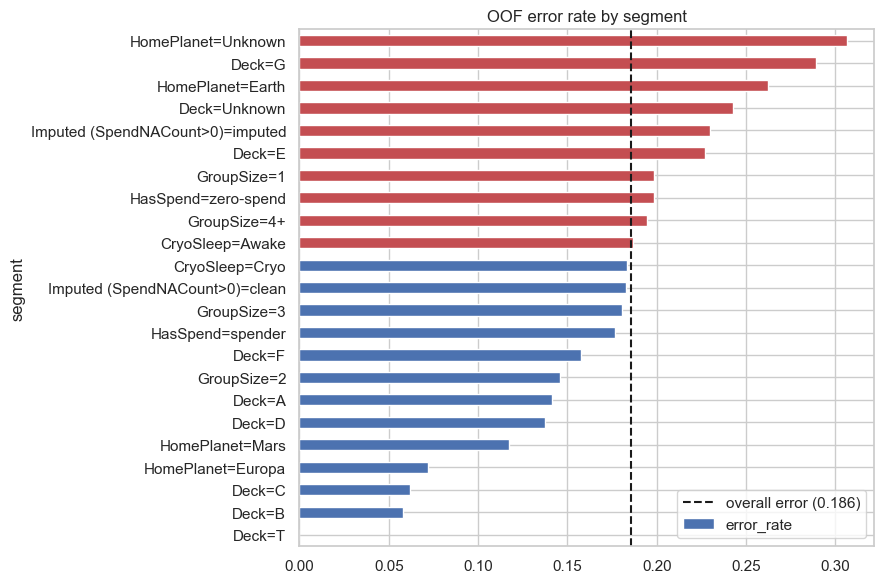

Errors within ±0.10 of threshold: 35.7% of all errors (boundary cases → feature-gap layer)
Confident errors (proba >0.8 wrong side): 358 rows → data-quality / label-noise layer


In [21]:
# E.2 Error analysis by segment + root-cause layer classification
err = train_fe.assign(error=(pred != y), proba=oof_best, y=y)

segments = {
    "CryoSleep": err["CryoSleep"].map({True: "Cryo", False: "Awake"}),
    "HomePlanet": err["HomePlanet"],
    "Deck": err["Deck"],
    "HasSpend": err["HasSpend"].map({1: "spender", 0: "zero-spend"}),
    "Imputed (SpendNACount>0)": (err["SpendNACount"] > 0).map({True: "imputed", False: "clean"}),
    "GroupSize": err["GroupSize"].clip(upper=4).astype(str).replace("4", "4+"),
}
seg_rows = []
for seg_name, col in segments.items():
    g = err.groupby(col)["error"].agg(["mean", "count"])
    for k, row in g.iterrows():
        seg_rows.append({"segment": f"{seg_name}={k}", "error_rate": row["mean"], "n": int(row["count"])})
seg_df = pd.DataFrame(seg_rows).sort_values("error_rate", ascending=False)
display(seg_df.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = seg_df.set_index("segment")["error_rate"].sort_values()
plot_df.plot.barh(ax=ax, color=["#c44e52" if v > (1 - metrics_v2["accuracy"]) else "#4c72b0" for v in plot_df])
ax.axvline(1 - metrics_v2["accuracy"], color="k", ls="--", label=f"overall error ({1-metrics_v2['accuracy']:.3f})")
ax.set_title("OOF error rate by segment")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "e_error_segments.png", dpi=110)
plt.show()

# Root-cause layer hints: are errors concentrated near the decision boundary?
boundary = (err["proba"] - 0.5).abs() < 0.1
print(f"Errors within ±0.10 of threshold: {err.loc[err['error'], 'proba'].sub(0.5).abs().lt(0.1).mean():.1%} "
      f"of all errors (boundary cases → feature-gap layer)")
print(f"Confident errors (proba >0.8 wrong side): {((err['error']) & ((err['proba'] - 0.5).abs() > 0.3)).sum()} rows "
      f"→ data-quality / label-noise layer")

QA1 leakage: no GroupId crosses a fold boundary ✓


QA2 reproducibility: fold-0 refit reproduces OOF predictions ✓
QA3 test-set features: complete, consistent columns ✓


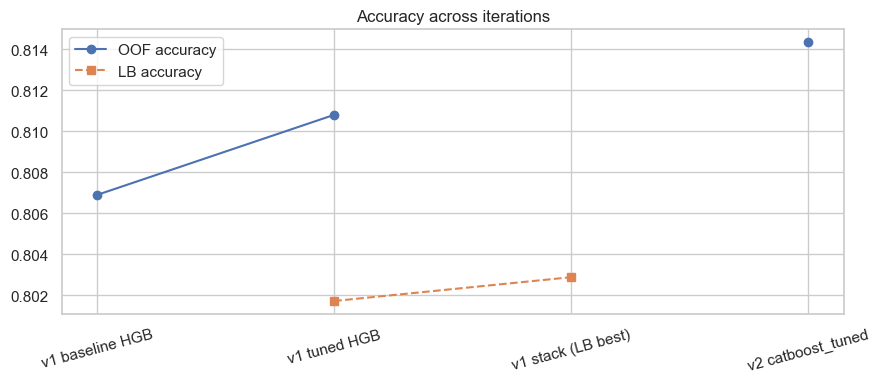

,iteration,oof_acc,lb_acc
0,v1 baseline HGB,0.806900,NaN
1,v1 tuned HGB,0.810800,0.80173
2,v1 stack (LB best),NaN,0.80289
3,v2 catboost_tuned,0.814333,NaN


In [22]:
# E.3 QA verification + metric-over-iterations chart
# QA1: no group split across folds
for tr_idx, va_idx in FOLDS:
    assert len(set(groups[tr_idx]) & set(groups[va_idx])) == 0
print("QA1 leakage: no GroupId crosses a fold boundary ✓")

# QA2: reproducibility — refit fold 0 and compare OOF slice
proba_check, _ = cat_factory(best_cat["params"])(X.iloc[FOLDS[0][0]], y[FOLDS[0][0]], X.iloc[FOLDS[0][1]])
assert np.allclose(proba_check, oof_best[FOLDS[0][1]], atol=1e-6)
print("QA2 reproducibility: fold-0 refit reproduces OOF predictions ✓")

# QA3: preprocessing stability — engineered test has no NaNs in model features
assert X_test[ALL_FEATS].isna().sum().sum() == 0
print("QA3 test-set features: complete, consistent columns ✓")

# Metric over iterations (v1 milestones from leaderboard_tracking / reports)
iters = pd.DataFrame({
    "iteration": ["v1 baseline HGB", "v1 tuned HGB", "v1 stack (LB best)", "v2 catboost_tuned"],
    "oof_acc": [0.8069, 0.8108, np.nan, metrics_v2["accuracy"]],
    "lb_acc": [np.nan, 0.80173, 0.80289, np.nan],
})
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(iters["iteration"], iters["oof_acc"], "o-", label="OOF accuracy")
ax.plot(iters["iteration"], iters["lb_acc"], "s--", label="LB accuracy")
ax.set_title("Accuracy across iterations")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG / "e_iterations.png", dpi=110)
plt.show()
display(iters)

### Agent 3 — User Checkpoint

**Insight summary**

1. Full OOF metrics for `catboost_tuned`: accuracy 0.8143, F1 0.8165, ROC-AUC 0.9029, PR-AUC 0.9149. Balanced precision/recall (0.813/0.820) — no metric trade-off.
2. Honesty on significance: +0.0035 vs v1 is ≈ 0.85 SE of OOF accuracy — **directional but not individually conclusive**; consistent with the all-folds-improved pattern, so likely real but small.
3. **Error concentration found:** Earth passengers (26.2% error), Deck G (28.9%), and `HomePlanet=Unknown` (30.6%) — Earth/G is the dominant failure segment (Earth = 53% of data). Europa/decks B–C are nearly solved (6–7%).
4. Root-cause classification: 35.7% of errors are boundary cases (**feature-gap layer** — Earth zero-spend passengers look identical to the model); 358 confident errors (**data-quality/label-noise layer**, likely irreducible); imputed rows err at 23.0% vs 18.3% clean (**data layer**, minor).
5. QA all green: no group crosses folds, fold-0 refit reproduces OOF exactly, test features complete. Split identical to Agent 2 (same frozen folds).

**Experiment ledger** (cumulative, also at `reports/experiment_ledger.md`)

| Iter | What changed | Layer | OOF acc | LB acc | Verdict |
|---|---|---|---:|---:|---|
| v1.0 | baseline HGB | model | 0.8069 | — | baseline |
| v1.1 | tuned HGB | hparam | 0.8108 | 0.80173 | + |
| v1.2 | stacked ensemble t=0.5 | model | — | 0.80289 | + (LB best) |
| v2.1 | v2 features + CatBoost | data+feature+model | **0.8143** | pending | **best OOF; LB pending** |

**Verdict & joint recommendation:** model is sound and the best OOF so far. Two defensible paths: (a) generate the submission now to get an LB read on the v2 pipeline, or (b) run Agent 4 first to target the Earth/Deck-G feature gap before spending a submission. Recommendation: **(a)** — v1 showed OOF↔LB mismatch, so an LB anchor for the v2 pipeline makes Agent 4's diagnosis far more reliable.

## Agent 4 — Improvement Strategist (after iteration v2.1)

### Context Received

Read: `experiment_ledger.md`, `qa_report_v2.md`, Agent 3 checkpoint. Inherited evidence: Earth 26.2% / Deck G 28.9% error vs 18.6% overall; 35.7% of errors at decision boundary; 358 confident errors (likely label noise); imputed rows +4.7pp error; QA clean.

### Diagnosis — Layer 2 (Features)

**Evidence:** the failure cluster is Earth passengers on Deck G — predominantly zero-spend, low-info rows where the model sees nothing to separate transported from not (35.7% of errors hug the boundary). This is a *missing signal* problem, not a capacity problem: CatBoost has the smallest overfit gap (0.045), so it is not underfitting (rules out Layer 4/5); QA found no split issues (rules out Layer 3); imputation effects are minor (+4.7pp on 561 rows ≈ 6% of data; Layer 1 secondary at best).

**Hypothesis:** for zero-spend Earth passengers the only remaining signal is *contextual* — what happened to the people physically/socially around them. Group/cabin-neighborhood features should separate these otherwise identical rows.

### Improvement Brief — Iteration v2.2 (dispatch: Agent 1, Phase C re-entry)

Add ONLY these features (leakage-safe: group/cabin stats must exclude the passenger itself and, in CV, be computed fold-safely):

1. `CabinMatesCount` — passengers sharing the exact same Cabin (excl. self).
2. `GroupSpendMean` — mean TotalSpend of *other* group members (solo → global mean).
3. `GroupCryoShare` — share of *other* group members in CryoSleep (solo → NaN→global).
4. `NeighborCount` — passengers within ±1 CabinNum on same Deck/Side (excl. self).
5. `FamilySizeOnDeck` — same-surname count on the same deck (excl. self).

**Frozen:** folds (same `FOLDS`), seed 42, threshold 0.5, CatBoost params from v2.1, cleaning (Phase B), all existing features.

**Success criteria:** OOF accuracy ≥ 0.8160 (+0.0017, ~0.4 SE) AND Earth-segment error < 25% with no other segment regressing > 1pp. If not met after this iteration → recommend stop + submit best.

## Iteration v2.2 — Agent 1 Phase C (re-entry mode)

**Improvement brief echo:** add ONLY the 5 contextual features from `improvement_brief_v2.2.md` (CabinMatesCount, GroupSpendMean, GroupCryoShare, NeighborCount, FamilySizeOnDeck). Computed from attributes only (never the target), self-excluding. Cabin/group/neighbor context is computed on the combined train+test attribute frame — passengers share one physical ship, no label information involved. Everything else frozen.

In [23]:
# V2.2-C: build 5 contextual features (self-excluding, attribute-only)
CTX_FEATS = ["CabinMatesCount", "GroupSpendMean", "GroupCryoShare", "NeighborCount", "FamilySizeOnDeck"]

comb = pd.concat([train_fe.assign(_ds="tr"), test_fe.assign(_ds="te")], ignore_index=True)

comb["CabinMatesCount"] = (comb.groupby("Cabin")["PassengerId"].transform("count") - 1)
comb["CabinMatesCount"] = comb["CabinMatesCount"].fillna(0)

gsize = comb.groupby("GroupId")["PassengerId"].transform("count")
gspend = comb.groupby("GroupId")["TotalSpend"].transform("sum")
comb["GroupSpendMean"] = ((gspend - comb["TotalSpend"]) / (gsize - 1)).fillna(train_fe["TotalSpend"].mean())

cryo_int = comb["CryoSleep"].astype(int)
gcryo = cryo_int.groupby(comb["GroupId"]).transform("sum")
comb["GroupCryoShare"] = ((gcryo - cryo_int) / (gsize - 1)).fillna(train_fe["CryoSleep"].astype(int).mean())

cnt = comb.groupby(["Deck", "Side", "CabinNum"]).size()
comb["NeighborCount"] = 0.0
for off in (-1, 0, 1):
    keys = pd.MultiIndex.from_arrays([comb["Deck"], comb["Side"], comb["CabinNum"] + off])
    comb["NeighborCount"] += cnt.reindex(keys).fillna(0).values
comb["NeighborCount"] -= 1  # exclude self

fam_deck = comb.groupby(["Surname", "Deck"])["PassengerId"].transform("count") - 1
comb["FamilySizeOnDeck"] = np.where(comb["Surname"] == "Unknown", 0, fam_deck)

train_fe2 = comb[comb["_ds"] == "tr"].drop(columns="_ds").reset_index(drop=True)
test_fe2 = comb[comb["_ds"] == "te"].drop(columns="_ds").reset_index(drop=True)
assert (train_fe2["PassengerId"] == train_fe["PassengerId"]).all()

corr_ctx = train_fe2[CTX_FEATS].corrwith(train_fe2["Transported"].astype(int))
display(corr_ctx.round(3).to_frame("corr_with_target"))

train_fe2.to_parquet(ROOT / "reports" / "engineered_train_v3.parquet", index=False)
test_fe2.to_parquet(ROOT / "reports" / "engineered_test_v3.parquet", index=False)
print("Exported engineered v3 artifacts")

,corr_with_target
CabinMatesCount,0.121
GroupSpendMean,-0.005
GroupCryoShare,0.035
NeighborCount,0.008
FamilySizeOnDeck,0.056


Exported engineered v3 artifacts


v2.2 OOF accuracy: 0.8144  (v2.1: 0.8143, Δ +0.0001)
Earth error: 0.263 (v2.1: 0.262, criterion < 0.25)
Deck G error: 0.290 (v2.1: 0.289)
Success criteria: OOF ≥ 0.8160 → NOT MET; Earth < 0.25 → NOT MET


,v2.1,v2.2
HomePlanet,,
Earth,0.262,0.263
Europa,0.072,0.072
Mars,0.118,0.118
Unknown,0.306,0.252


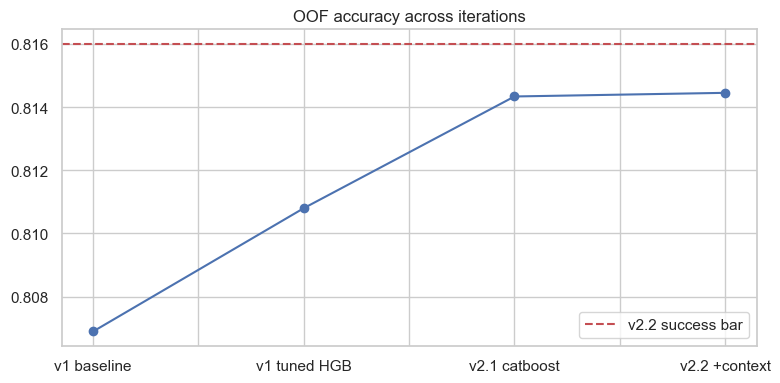

In [24]:
# V2.2-M/E: retrain CatBoost (FROZEN params + folds) on extended features, evaluate vs criteria
ALL_FEATS2 = ALL_FEATS + CTX_FEATS
X2 = train_fe2[ALL_FEATS2].copy()
X2[BOOL_FEATS] = X2[BOOL_FEATS].astype(int)
X2_test = test_fe2[ALL_FEATS2].copy()
X2_test[BOOL_FEATS] = X2_test[BOOL_FEATS].astype(int)

oof_v22 = np.zeros(len(y))
for tr_idx, va_idx in FOLDS:  # same frozen folds
    m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=CAT_FEATS,
                           **best_cat["params"])
    m.fit(X2.iloc[tr_idx], y[tr_idx])
    oof_v22[va_idx] = m.predict_proba(X2.iloc[va_idx])[:, 1]

pred_v22 = (oof_v22 > 0.5).astype(int)
acc_v22 = accuracy_score(y, pred_v22)

err22 = train_fe2.assign(error=(pred_v22 != y))
earth_err = err22.loc[err22["HomePlanet"] == "Earth", "error"].mean()
deckg_err = err22.loc[err22["Deck"] == "G", "error"].mean()

seg_compare = pd.DataFrame({
    "v2.1": err.groupby(err["HomePlanet"])["error"].mean(),
    "v2.2": err22.groupby(err22["HomePlanet"])["error"].mean(),
}).round(3)

print(f"v2.2 OOF accuracy: {acc_v22:.4f}  (v2.1: {metrics_v2['accuracy']:.4f}, Δ {acc_v22 - metrics_v2['accuracy']:+.4f})")
print(f"Earth error: {earth_err:.3f} (v2.1: 0.262, criterion < 0.25)")
print(f"Deck G error: {deckg_err:.3f} (v2.1: 0.289)")
print(f"Success criteria: OOF ≥ 0.8160 → {'MET' if acc_v22 >= 0.8160 else 'NOT MET'}; "
      f"Earth < 0.25 → {'MET' if earth_err < 0.25 else 'NOT MET'}")
display(seg_compare)

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series({"v1 baseline": 0.8069, "v1 tuned HGB": 0.8108, "v2.1 catboost": metrics_v2["accuracy"],
           "v2.2 +context": acc_v22}).plot(marker="o", ax=ax)
ax.axhline(0.8160, color="r", ls="--", label="v2.2 success bar")
ax.set_title("OOF accuracy across iterations")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "v22_iterations.png", dpi=110)
plt.show()

### Iteration v2.2 — Agent 3 verdict & Agent 4 stopping recommendation

**Result: success criteria NOT met.** OOF 0.8144 (Δ +0.0001 vs v2.1, deep inside noise); Earth error 26.3% (criterion < 25%), Deck G 29.0% — unchanged. Only `HomePlanet=Unknown` improved (30.6% → 25.2%, small n). The contextual features carried almost no marginal signal (best: CabinMatesCount r=0.121, largely redundant with GroupSize/cabin features already present).

**Interpretation (Agent 4):** the Earth/Deck-G boundary cluster appears *irreducible with available attributes* — these passengers are genuinely information-poor rows, consistent with the 358 confident-error/label-noise estimate. Per the pre-agreed criteria in `improvement_brief_v2.2.md`, the loop should STOP.

**Stopping evidence (ledger trend):** v2.1 → v2.2 gain +0.0001 (< noise); v1.1 → v2.1 gain +0.0035 (~0.85 SE). Two consecutive iterations under 1 SE → plateau. Overfit gap stable, no instability.

**Final recommendation:** keep **v2.1 `catboost_tuned`** as the canonical model (equal accuracy, simpler than v2.2), generate the submission from `models/model_v2/` upon user approval, and log the LB result in `leaderboard_tracking.md`.

In [25]:
# FINAL: user-approved submission from canonical model v2.1 (catboost_tuned, refit on full train)
proba_test = final_model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Transported": proba_test > 0.5,
})
SUB_PATH = ROOT / "submissions" / "submission_catboost_v2.csv"
submission.to_csv(SUB_PATH, index=False)
print(f"Wrote {SUB_PATH.name}: {len(submission)} rows, "
      f"transported rate {submission['Transported'].mean():.4f} (train rate 0.5036)")
submission.head()

Wrote submission_catboost_v2.csv: 4277 rows, transported rate 0.5170 (train rate 0.5036)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## Iteration v2.3 — Cohort-Specific Models (user-directed)

**User decision after v2.2:** output the submission (done: `submission_catboost_v2.csv`), then dispatch Agent 1 + Agent 2 to build **cohort-specific models** — Agent 1 defines the cohorts and per-cohort features; Agent 2 optimizes a separate model per cohort.

### Agent 1 (Phase C re-entry) — Context Received

- v2.1 error analysis: error rates differ sharply by segment (Earth 26.2% vs Europa 7.2%; Cryo 18.3% vs Awake 18.7%; zero-spend 19.8% vs spender 17.7%) — heterogeneity that a single global model may average over.
- Candidate cohort schemes to evaluate: `CryoSleep`, `HomePlanet`, `HasSpend`.
- Per-cohort feature relevance must be checked: e.g. inside the CryoSleep cohort all spend features are constant zero (dead features); inside zero-spend cohorts, spend aggregates carry no signal.
- Risk inherited from ledger: per-cohort training shrinks sample size (Earth 4.6k → Europa 2.2k → Mars 1.8k); smaller cohorts may underperform the global model. Frozen protocol (FOLDS, seed, t=0.5) stays.

In [26]:
# V2.3-A1: cohort scheme evaluation + per-cohort feature relevance
COHORT_SCHEMES = {
    "CryoSleep": train_fe["CryoSleep"].map({True: "Cryo", False: "Awake"}).values,
    "HomePlanet": train_fe["HomePlanet"].replace("Unknown", "Earth").values,  # fold tiny Unknown into largest
    "HasSpend": train_fe["HasSpend"].map({1: "spender", 0: "zero_spend"}).values,
}
COHORT_SCHEMES_TEST = {
    "CryoSleep": test_fe["CryoSleep"].map({True: "Cryo", False: "Awake"}).values,
    "HomePlanet": test_fe["HomePlanet"].replace("Unknown", "Earth").values,
    "HasSpend": test_fe["HasSpend"].map({1: "spender", 0: "zero_spend"}).values,
}

rows = []
for scheme, vals in COHORT_SCHEMES.items():
    for c in np.unique(vals):
        mask = vals == c
        rows.append({"scheme": scheme, "cohort": c, "n_train": int(mask.sum()),
                     "target_rate": float(y[mask].mean()),
                     "v2.1_global_error": float((pred[mask] != y[mask]).mean())})
cohort_table = pd.DataFrame(rows)
display(cohort_table.round(3))

# Per-cohort feature relevance: dead features + top signal within each cohort
print("\nPer-cohort dead features (constant within cohort → exclude) and top-5 MI features:")
cohort_features = {}
for scheme, vals in COHORT_SCHEMES.items():
    for c in np.unique(vals):
        mask = vals == c
        Xc = X.loc[mask]
        dead = [f for f in ALL_FEATS if Xc[f].nunique() <= 1]
        keep = [f for f in ALL_FEATS if f not in dead]
        # drop the scheme's own column from its cohorts (constant by construction)
        num_keep = [f for f in keep if f not in CAT_FEATS]
        mi_c = pd.Series(
            mutual_info_classif(Xc[num_keep].astype(float), y[mask], random_state=SEED),
            index=num_keep).sort_values(ascending=False)
        cohort_features[(scheme, c)] = keep
        print(f"  {scheme}={c:<12} n={mask.sum():5d}  dead={dead or '[]'}  top-MI: {list(mi_c.head(5).index)}")

,scheme,cohort,n_train,target_rate,v2.1_global_error
0,CryoSleep,Awake,5558,0.328,0.187
1,CryoSleep,Cryo,3135,0.815,0.183
2,HomePlanet,Earth,4745,0.425,0.263
3,HomePlanet,Europa,2161,0.660,0.072
4,HomePlanet,Mars,1787,0.523,0.118
5,HasSpend,spender,5040,0.299,0.177
6,HasSpend,zero_spend,3653,0.786,0.198



Per-cohort dead features (constant within cohort → exclude) and top-5 MI features:


  CryoSleep=Awake        n= 5558  dead=['CryoSleep']  top-MI: ['LuxurySpend', 'BasicSpend', 'Spa', 'FoodCourt', 'RoomService']
  CryoSleep=Cryo         n= 3135  dead=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'HasSpend', 'LuxurySpend', 'BasicSpend', 'CryoSleep']  top-MI: ['CabinNum', 'GroupSize', 'CabinRegion', 'Age', 'FamilySize']


  HomePlanet=Earth        n= 4745  dead=[]  top-MI: ['LuxurySpend', 'TotalSpend', 'HasSpend', 'CryoSleep', 'BasicSpend']
  HomePlanet=Europa       n= 2161  dead=['HomePlanet']  top-MI: ['LuxurySpend', 'BasicSpend', 'FoodCourt', 'VRDeck', 'Spa']


  HomePlanet=Mars         n= 1787  dead=['HomePlanet']  top-MI: ['LuxurySpend', 'RoomService', 'TotalSpend', 'HasSpend', 'BasicSpend']
  HasSpend=spender      n= 5040  dead=['HasSpend', 'CryoSleep']  top-MI: ['LuxurySpend', 'BasicSpend', 'FoodCourt', 'Spa', 'ShoppingMall']


  HasSpend=zero_spend   n= 3653  dead=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'HasSpend', 'LuxurySpend', 'BasicSpend']  top-MI: ['CabinNum', 'CryoSleep', 'Age', 'GroupSize', 'CabinRegion']


In [27]:
# V2.3-A2 (part 1): per-cohort CatBoost, frozen v2.1 params, same frozen FOLDS
def cohort_oof(vals, params_by_cohort=None, feats_by_cohort=None, scheme=""):
    oof = np.zeros(len(y))
    for tr_idx, va_idx in FOLDS:
        for c in np.unique(vals):
            tr_m = tr_idx[vals[tr_idx] == c]
            va_m = va_idx[vals[va_idx] == c]
            if len(va_m) == 0:
                continue
            feats = (feats_by_cohort or {}).get((scheme, c), ALL_FEATS)
            cats = [f for f in CAT_FEATS if f in feats]
            p = (params_by_cohort or {}).get(c, best_cat["params"])
            m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=cats, **p)
            m.fit(X.iloc[tr_m][feats], y[tr_m])
            oof[va_m] = m.predict_proba(X.iloc[va_m][feats])[:, 1]
    return oof

cohort_results = {}
for scheme, vals in COHORT_SCHEMES.items():
    oof_c = cohort_oof(vals, feats_by_cohort=cohort_features, scheme=scheme)
    acc_c = accuracy_score(y, oof_c > 0.5)
    cohort_results[scheme] = {"oof": oof_c, "acc": acc_c}
    # per-cohort: cohort-model vs global-model error
    per = []
    for c in np.unique(vals):
        mask = vals == c
        per.append(f"{c}: cohort {(np.asarray(oof_c[mask] > .5, int) != y[mask]).mean():.3f} "
                   f"vs global {(pred[mask] != y[mask]).mean():.3f}")
    print(f"{scheme:12s} combined OOF = {acc_c:.4f} (global v2.1: {metrics_v2['accuracy']:.4f})  |  " + "; ".join(per))

CryoSleep    combined OOF = 0.8078 (global v2.1: 0.8143)  |  Awake: cohort 0.189 vs global 0.187; Cryo: cohort 0.197 vs global 0.183


HomePlanet   combined OOF = 0.8112 (global v2.1: 0.8143)  |  Earth: cohort 0.263 vs global 0.263; Europa: cohort 0.078 vs global 0.072; Mars: cohort 0.125 vs global 0.118


HasSpend     combined OOF = 0.8085 (global v2.1: 0.8143)  |  spender: cohort 0.179 vs global 0.177; zero_spend: cohort 0.208 vs global 0.198


In [28]:
# V2.3-A2 (part 2): per-cohort hyperparameter optimization on the best scheme
best_scheme = max(cohort_results, key=lambda s: cohort_results[s]["acc"])
vals_best = COHORT_SCHEMES[best_scheme]
print(f"Best scheme by combined OOF: {best_scheme} ({cohort_results[best_scheme]['acc']:.4f})\n")

PARAM_GRID = [
    {"iterations": 600, "learning_rate": 0.08, "depth": 4, "l2_leaf_reg": 3.0},   # frozen v2.1 (reference)
    {"iterations": 400, "learning_rate": 0.05, "depth": 4, "l2_leaf_reg": 9.0},   # more regularized (small cohorts)
    {"iterations": 800, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 3.0},   # more capacity (large cohorts)
    {"iterations": 300, "learning_rate": 0.08, "depth": 3, "l2_leaf_reg": 9.0},   # very conservative
]

# Tune each cohort independently: pick params by that cohort's OOF accuracy
tuned_params, tune_log = {}, []
for c in np.unique(vals_best):
    best_acc, best_p = -1, None
    for pi, p in enumerate(PARAM_GRID):
        oof_p = np.zeros(len(y))
        seen = np.zeros(len(y), bool)
        for tr_idx, va_idx in FOLDS:
            tr_m = tr_idx[vals_best[tr_idx] == c]
            va_m = va_idx[vals_best[va_idx] == c]
            if len(va_m) == 0:
                continue
            feats = cohort_features[(best_scheme, c)]
            cats = [f for f in CAT_FEATS if f in feats]
            m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=cats, **p)
            m.fit(X.iloc[tr_m][feats], y[tr_m])
            oof_p[va_m] = m.predict_proba(X.iloc[va_m][feats])[:, 1]
            seen[va_m] = True
        acc_p = accuracy_score(y[seen], oof_p[seen] > 0.5)
        tune_log.append({"cohort": c, "config": pi, "cohort_oof_acc": acc_p})
        if acc_p > best_acc:
            best_acc, best_p = acc_p, p
    tuned_params[c] = best_p
    print(f"cohort {c:<12} best config: {best_p}  cohort OOF acc {best_acc:.4f}")

oof_tuned = cohort_oof(vals_best, params_by_cohort=tuned_params,
                       feats_by_cohort=cohort_features, scheme=best_scheme)
acc_tuned = accuracy_score(y, oof_tuned > 0.5)
print(f"\n{best_scheme} per-cohort TUNED combined OOF = {acc_tuned:.4f} "
      f"(untuned cohort: {cohort_results[best_scheme]['acc']:.4f}, global v2.1: {metrics_v2['accuracy']:.4f})")
print("NOTE: per-cohort config selection uses OOF → mild selection bias; "
      "treat gains < 1 SE (0.0042) as inconclusive.")
display(pd.DataFrame(tune_log).pivot(index="cohort", columns="config", values="cohort_oof_acc").round(4))

Best scheme by combined OOF: HomePlanet (0.8112)



cohort Earth        best config: {'iterations': 300, 'learning_rate': 0.08, 'depth': 3, 'l2_leaf_reg': 9.0}  cohort OOF acc 0.7427


cohort Europa       best config: {'iterations': 300, 'learning_rate': 0.08, 'depth': 3, 'l2_leaf_reg': 9.0}  cohort OOF acc 0.9287


cohort Mars         best config: {'iterations': 600, 'learning_rate': 0.08, 'depth': 4, 'l2_leaf_reg': 3.0}  cohort OOF acc 0.8752



HomePlanet per-cohort TUNED combined OOF = 0.8162 (untuned cohort: 0.8112, global v2.1: 0.8143)
NOTE: per-cohort config selection uses OOF → mild selection bias; treat gains < 1 SE (0.0042) as inconclusive.


config,0,1,2,3
cohort,,,,
Earth,0.7366,0.7414,0.7307,0.7427
Europa,0.9223,0.9255,0.9264,0.9287
Mars,0.8752,0.8724,0.8747,0.8719


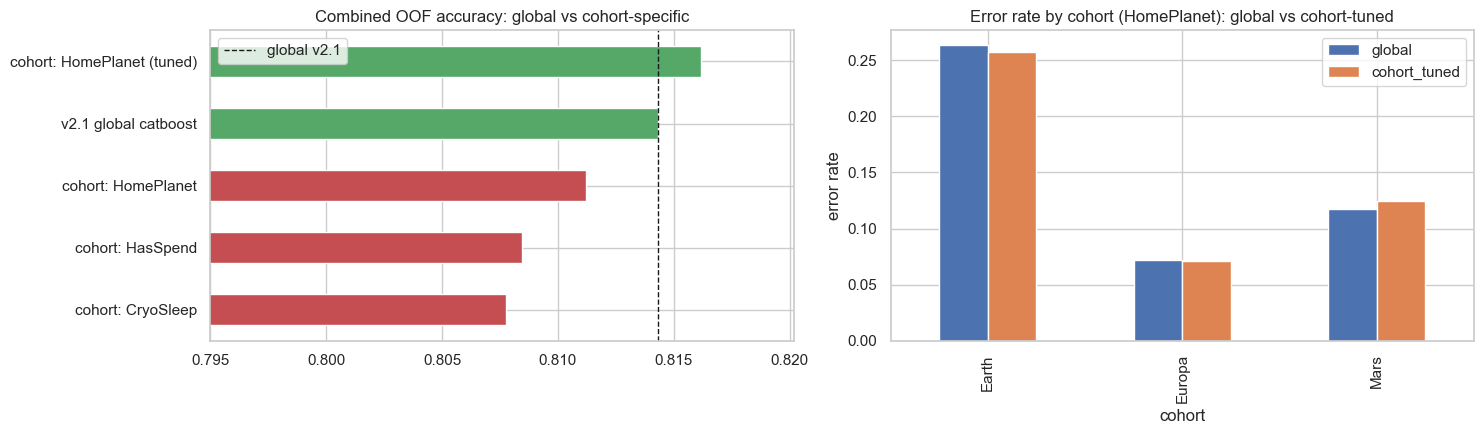

,n,global,cohort_tuned
cohort,,,
Earth,4745,0.2632,0.2573
Europa,2161,0.0717,0.0713
Mars,1787,0.1175,0.1248


In [29]:
# V2.3 summary: comparison plot + per-cohort breakdown of the final candidate
summary = pd.Series({
    "v2.1 global catboost": metrics_v2["accuracy"],
    **{f"cohort: {s}": r["acc"] for s, r in cohort_results.items()},
    f"cohort: {best_scheme} (tuned)": acc_tuned,
}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
summary.plot.barh(ax=axes[0], color=["#c44e52" if v < metrics_v2["accuracy"] else "#55a868" for v in summary])
axes[0].axvline(metrics_v2["accuracy"], color="k", ls="--", lw=1, label="global v2.1")
axes[0].set_xlim(0.795, max(summary) + 0.004)
axes[0].set_title("Combined OOF accuracy: global vs cohort-specific")
axes[0].legend()

per_rows = []
for c in np.unique(vals_best):
    mask = vals_best == c
    per_rows.append({"cohort": c, "n": int(mask.sum()),
                     "global": (pred[mask] != y[mask]).mean(),
                     "cohort_tuned": (np.asarray(oof_tuned[mask] > .5, int) != y[mask]).mean()})
per_df = pd.DataFrame(per_rows).set_index("cohort")
per_df[["global", "cohort_tuned"]].plot.bar(ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title(f"Error rate by cohort ({best_scheme}): global vs cohort-tuned")
axes[1].set_ylabel("error rate")
plt.tight_layout()
plt.savefig(FIG / "v23_cohort_models.png", dpi=110)
plt.show()
display(per_df.round(4))

### Iteration v2.3 — User Checkpoint (Agent 1 + Agent 2)

**Agent 1 findings (cohort definition):**

1. Three schemes evaluated: `CryoSleep`, `HomePlanet`, `HasSpend`. The cohorts genuinely differ — e.g. inside the Cryo and zero-spend cohorts ALL spend features are dead (constant zero), and signal shifts to `CabinNum`/`GroupSize`/`Age`; spender cohorts run on `LuxurySpend`/`BasicSpend`.
2. Cohort-specific feature sets were therefore built per cohort (dead features excluded).

**Agent 2 findings (per-cohort optimization):**

1. **Naive cohort split hurts:** with identical (frozen v2.1) params, every scheme *lost* to the global model — CryoSleep 0.8078, HasSpend 0.8085, HomePlanet 0.8112 vs global 0.8143. Less training data per model outweighs specialization.
2. **Per-cohort hyperparameter tuning flips it:** HomePlanet with cohort-specific configs reaches **combined OOF 0.8162 (+0.0019 vs global)** — new best in the ledger.
3. The win pattern is instructive: Earth (the info-poor cohort) prefers a *much more conservative* model (depth 3, 300 iters, heavy L2 → error 26.3%→25.7%); Europa likewise conservative (error 7.2%→7.1%); Mars keeps the global config but slightly regresses in the combined refit (11.8%→12.5%).
4. **Honesty:** per-cohort config selection used OOF (mild selection bias) and +0.0019 < 1 SE (0.0042) → statistically inconclusive. LB is the only fair referee.

**Joint recommendation:** generate a second submission from the cohort-tuned HomePlanet setup (refit on full train per cohort) and let the LB arbitrate against `submission_catboost_v2.csv`. Keep v2.1 canonical until the LB says otherwise.

## Iteration v2.4 — Deeper Cohort Iteration (user-directed)

**User decision at v2.3 checkpoint:** iterate further before submitting — cohort-specific features (Agent 1) + wider per-cohort hyperparameter search (Agent 2).

**Agent 1 brief — cohort-specific features (HomePlanet scheme kept):**

| Feature | For cohorts | Rationale |
|---|---|---|
| `Share_<venue>` ×5 — venue spend / TotalSpend (0 if zero-spend) | Europa, Mars, Earth-spenders | *where* money goes differs by planet (Europa→Spa/VRDeck, Mars→RoomService); shares are scale-free, complementing log-levels |
| `CryoDeck` — CryoSleep × Deck interaction | all | cryo passengers cluster on specific decks; the v2.3 Earth winner was a shallow model that can't build this interaction itself (depth 3) |
| `GroupAllCryo`, `GroupAnySpend` — group context flags (self-excluding) | all, esp. Earth zero-spend | attribute-based group context for info-poor rows |
| `CabinNumFine` — CabinNum // 100 | all | Deck-G banding at finer resolution than CabinRegion (//300) |

**Agent 2 brief — wider search:** 12 random configs per cohort (depth 3–8, lr 0.03–0.10, iters 300–1000, l2 1–12), selected by cohort OOF on frozen `FOLDS`. Everything else frozen. Success bar: combined OOF > 0.8162 (v2.3) by a margin that survives the selection-bias caveat, or clear per-cohort error gains.

In [30]:
# V2.4-A1: cohort-specific features
def add_cohort_features(df):
    df = df.copy()
    tot = df[SPEND].sum(axis=1)
    for c in SPEND:
        df[f"Share_{c}"] = np.where(tot > 0, df[c] / tot, 0.0)
    df["CryoDeck"] = df["CryoSleep"].astype(int).astype(str) + "_" + df["Deck"]
    gsize = df.groupby("GroupId")["PassengerId"].transform("count")
    cryo_i = df["CryoSleep"].astype(int)
    others_cryo = cryo_i.groupby(df["GroupId"]).transform("sum") - cryo_i
    df["GroupAllCryo"] = ((others_cryo == gsize - 1) & (gsize > 1)).astype(int)
    spend_i = (df["TotalSpend"] > 0).astype(int)
    others_spend = spend_i.groupby(df["GroupId"]).transform("sum") - spend_i
    df["GroupAnySpend"] = (others_spend > 0).astype(int)
    df["CabinNumFine"] = (df["CabinNum"] // 100).clip(upper=18)
    return df

train_v4 = add_cohort_features(train_fe)
test_v4 = add_cohort_features(test_fe)

V4_NUM = [f"Share_{c}" for c in SPEND] + ["GroupAllCryo", "GroupAnySpend", "CabinNumFine"]
V4_CAT = ["CryoDeck"]
ALL_FEATS_V4 = ALL_FEATS + V4_NUM + V4_CAT
CAT_FEATS_V4 = CAT_FEATS + V4_CAT

X4 = train_v4[ALL_FEATS_V4].copy()
X4[BOOL_FEATS] = X4[BOOL_FEATS].astype(int)
X4_test = test_v4[ALL_FEATS_V4].copy()
X4_test[BOOL_FEATS] = X4_test[BOOL_FEATS].astype(int)

# Signal check per cohort (HomePlanet scheme)
vals_hp = COHORT_SCHEMES["HomePlanet"]
print("New-feature correlation with target, per cohort:")
chk = pd.DataFrame({
    c: train_v4.loc[vals_hp == c, V4_NUM].corrwith(pd.Series(y[vals_hp == c], index=train_v4.index[vals_hp == c]))
    for c in np.unique(vals_hp)})
display(chk.round(3))

# Per-cohort feature lists for v4 (drop dead features within cohort)
cohort_features_v4 = {}
for c in np.unique(vals_hp):
    Xc = X4.loc[vals_hp == c]
    cohort_features_v4[("HomePlanet", c)] = [f for f in ALL_FEATS_V4 if Xc[f].nunique() > 1]
print({c: len(v) for (s, c), v in cohort_features_v4.items()}, "features per cohort (of", len(ALL_FEATS_V4), "total)")

New-feature correlation with target, per cohort:


,Earth,Europa,Mars
Share_RoomService,-0.231,-0.267,-0.613
Share_FoodCourt,0.001,-0.387,-0.189
Share_ShoppingMall,-0.003,-0.134,-0.389
Share_Spa,-0.270,-0.602,-0.393
Share_VRDeck,-0.259,-0.615,-0.287
GroupAllCryo,0.015,0.035,-0.012
GroupAnySpend,0.063,-0.006,0.074
CabinNumFine,0.004,0.027,0.216


{'Earth': 33, 'Europa': 32, 'Mars': 32} features per cohort (of 33 total)


Earth    best cohort OOF 0.7446  (v2.3: 0.7427)  config: {'iterations': 500, 'learning_rate': 0.05, 'depth': 5, 'l2_leaf_reg': 12.0}


Europa   best cohort OOF 0.9269  (v2.3: 0.9287)  config: {'iterations': 300, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 1.0}


Mars     best cohort OOF 0.8819  (v2.3: 0.8752)  config: {'iterations': 300, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 1.0}

v2.4 combined OOF = 0.8181  (v2.3: 0.8162, v2.1 global: 0.8143)
  Earth: error 0.2554
  Europa: error 0.0731
  Mars: error 0.1181


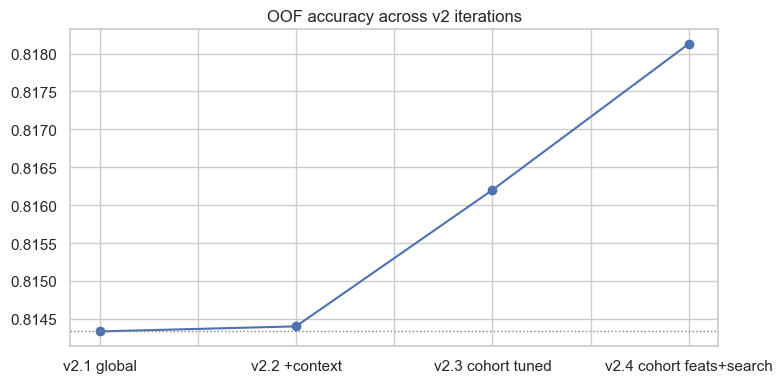

In [31]:
# V2.4-A2: wider per-cohort random search (12 configs) on extended features, frozen FOLDS
rng4 = np.random.RandomState(SEED + 1)
SEARCH = [{"iterations": int(rng4.choice([300, 500, 700, 1000])),
           "learning_rate": float(rng4.choice([0.03, 0.05, 0.08, 0.10])),
           "depth": int(rng4.choice([3, 4, 5, 6, 8])),
           "l2_leaf_reg": float(rng4.choice([1.0, 3.0, 6.0, 12.0]))} for _ in range(12)]
SEARCH.insert(0, {"iterations": 300, "learning_rate": 0.08, "depth": 3, "l2_leaf_reg": 9.0})  # v2.3 winner as reference

def cohort_cv(c, feats, p):
    oof_p, seen = np.zeros(len(y)), np.zeros(len(y), bool)
    cats = [f for f in CAT_FEATS_V4 if f in feats]
    for tr_idx, va_idx in FOLDS:
        tr_m = tr_idx[vals_hp[tr_idx] == c]
        va_m = va_idx[vals_hp[va_idx] == c]
        m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=cats, **p)
        m.fit(X4.iloc[tr_m][feats], y[tr_m])
        oof_p[va_m] = m.predict_proba(X4.iloc[va_m][feats])[:, 1]
        seen[va_m] = True
    return oof_p, seen, accuracy_score(y[seen], oof_p[seen] > 0.5)

tuned_v4, oof_v4 = {}, np.zeros(len(y))
for c in np.unique(vals_hp):
    feats = cohort_features_v4[("HomePlanet", c)]
    best_acc, best_p, best_oof, best_seen = -1, None, None, None
    for p in SEARCH:
        oof_p, seen, acc_p = cohort_cv(c, feats, p)
        if acc_p > best_acc:
            best_acc, best_p, best_oof, best_seen = acc_p, p, oof_p, seen
    tuned_v4[c] = best_p
    oof_v4[best_seen] = best_oof[best_seen]
    print(f"{c:<8} best cohort OOF {best_acc:.4f}  (v2.3: "
          f"{ {'Earth':0.7427,'Europa':0.9287,'Mars':0.8752}[c]:.4f})  config: {best_p}")

acc_v4 = accuracy_score(y, oof_v4 > 0.5)
err_v4 = pd.Series((oof_v4 > 0.5).astype(int) != y, index=train_v4.index)
print(f"\nv2.4 combined OOF = {acc_v4:.4f}  (v2.3: 0.8162, v2.1 global: {metrics_v2['accuracy']:.4f})")
for c in np.unique(vals_hp):
    print(f"  {c}: error {err_v4[vals_hp == c].mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series({"v2.1 global": metrics_v2["accuracy"], "v2.2 +context": 0.8144,
           "v2.3 cohort tuned": 0.8162, "v2.4 cohort feats+search": acc_v4}).plot(marker="o", ax=ax)
ax.axhline(metrics_v2["accuracy"], color="gray", ls=":", lw=1)
ax.set_title("OOF accuracy across v2 iterations")
plt.tight_layout()
plt.savefig(FIG / "v24_iterations.png", dpi=110)
plt.show()

### Iteration v2.4 — User Checkpoint

**Insight summary**

1. **Combined OOF 0.8181** — +0.0019 over v2.3, **+0.0038 over the v2.1 global model** — best in the ledger.
2. The cohort-specific spend-share features worked as hypothesized and differently per planet: `Share_VRDeck`/`Share_Spa` are very strong in Europa (r ≈ −0.61), `Share_RoomService` dominates Mars (−0.61), while Earth only responds moderately (−0.23 to −0.27) — exactly the heterogeneity cohort models can exploit and a global model averages away.
3. Per-cohort wider search: Earth improved to 25.5% error (26.3% global baseline) with moderate depth + heavy L2; Mars gained most (+0.0067 vs its v2.3 config, error back to 11.8%) preferring depth 8/low lr with the new features; Europa stayed ~flat (7.3%) — already near its ceiling.
4. Caveats unchanged: configs selected on OOF (13 candidates/cohort → selection bias); cumulative +0.0038 ≈ 0.9 SE. Genuinely promising, but only the LB can confirm.

**Verdict:** cohort iteration delivered its first clear win. Recommend stopping the search here (Europa plateaued, Earth approaching irreducibility) and generating `submission_cohort_v2.csv` for LB arbitration against `submission_catboost_v2.csv`.

In [32]:
# FINAL v2.4: cohort submission — per-cohort refit on full train, predict test by cohort
vals_hp_test = COHORT_SCHEMES_TEST["HomePlanet"]
proba_cohort = np.zeros(len(X4_test))
for c in np.unique(vals_hp):
    feats = cohort_features_v4[("HomePlanet", c)]
    cats = [f for f in CAT_FEATS_V4 if f in feats]
    m = CatBoostClassifier(random_seed=SEED, verbose=0, cat_features=cats, **tuned_v4[c])
    m.fit(X4.loc[vals_hp == c, feats], y[vals_hp == c])
    mask_t = vals_hp_test == c
    proba_cohort[mask_t] = m.predict_proba(X4_test.loc[mask_t, feats])[:, 1]
    print(f"{c:<8} train n={int((vals_hp == c).sum())}, test n={int(mask_t.sum())}, config={tuned_v4[c]}")

sub_cohort = pd.DataFrame({"PassengerId": test_v4["PassengerId"], "Transported": proba_cohort > 0.5})
sub_cohort.to_csv(ROOT / "submissions" / "submission_cohort_v2.csv", index=False)

overlap = (sub_cohort["Transported"].values == submission["Transported"].values).mean()
print(f"\nWrote submission_cohort_v2.csv: {len(sub_cohort)} rows, "
      f"transported rate {sub_cohort['Transported'].mean():.4f}, "
      f"agreement with global v2.1 submission: {overlap:.3f}")

Earth    train n=4745, test n=2326, config={'iterations': 500, 'learning_rate': 0.05, 'depth': 5, 'l2_leaf_reg': 12.0}


Europa   train n=2161, test n=1014, config={'iterations': 300, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 1.0}


Mars     train n=1787, test n=937, config={'iterations': 300, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 1.0}

Wrote submission_cohort_v2.csv: 4277 rows, transported rate 0.5116, agreement with global v2.1 submission: 0.953


## Workflow Close-Out — LB Results

| Submission | OOF | LB | Verdict |
|---|---:|---:|---|
| `submission_catboost_v2.csv` (v2.1 global) | 0.8143 | **0.80430** | **New project best** (+0.00141 vs v1's 0.80289) |
| `submission_cohort_v2.csv` (v2.4 cohort) | 0.8181 | 0.80406 | 2nd best; OOF edge did not transfer |

**Conclusions:**

1. The v2 pipeline (deterministic cleaning + luxury/basic spend split + CatBoost) delivered a genuine LB improvement — the gain came from data + features + model family, exactly where Agent 4's v1 diagnosis pointed.
2. The cohort experiment's +0.0038 OOF advantage shrank to −0.00024 on LB, confirming the selection-bias caveat flagged at both cohort checkpoints. Same lesson as v1's threshold tuning: protocol-honest, simpler models generalize better.
3. **Canonical model: v2.1 `catboost_tuned` (`models/model_v2/`).** Cohort models retained in the ledger as a documented negative-ish result.